# Crop Yield Prediction
### CipherSense AI — Machine Learning Engineer Intern Technical Assessment

---

**Author:** Nwachukwu Sarah  
**Dataset:** [ Crop Yield Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset)  
**Objective:** Build a reproducible machine learning pipeline that predicts crop yield (hg/ha) from environmental and agricultural features.

---

## Project Structure

```
ml-crop-yield-project/
├── data/
│   ├── raw/                  ← original Kaggle dataset
│   └── processed/            ← cleaned and feature-engineered dataset
├── notebooks/
│   └── exploration.ipynb     ← this notebook
├── src/
│   ├── data_cleaning.py      ← reusable cleaning pipeline
│   ├── preprocessing.py      ← sklearn preprocessing pipeline
│   ├── train_model.py        ← model training script
│   └── evaluate_model.py     ← model evaluation script
├── models/
│   └── trained_model.pkl     ← saved best model
├── requirements.txt
└── README.md
```

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| 1. Setup | Library imports and dataset loading |
| 2. EDA Part 1 | Dataset structure, types, missing values, duplicates |
| 3. EDA Part 2 | Feature distributions and categorical analysis |
| 4. EDA Part 3 | Outlier detection and investigation |
| 5. EDA Part 4 | Relationship and correlation analysis |
| 6. Data Cleaning | Formal cleaning pipeline applied to raw data |
| 7. Feature Engineering | Derived features from domain knowledge |


---
## Section 1 — Setup and Data Loading

All required libraries are imported here. The dataset is loaded directly from the uploaded CSV file.


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# ── Plot styling ──────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [115]:
df = pd.read_csv('/content/yield_df.csv')
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


---
## Section 2 — EDA Part 1: Dataset Structure

Before any cleaning or modelling, we inspect the raw dataset to understand its shape,
data types, and quality issues such as missing values and duplicates.

**Goals:**
- Understand dataset dimensions and column names
- Check data types for each feature
- Identify missing values and their extent
- Detect and quantify duplicate rows
- Generate basic summary statistics


In [116]:
print("=" * 45)
print("DATASET SHAPE & COLUMNS")
print("=" * 45)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

DATASET SHAPE & COLUMNS
Rows    : 28242
Columns : 8

Column names:
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


In [117]:
# 'Unnamed: 0' is just a leftover row index from when the CSV was saved.
# It carries no information so we drop it immediately.
df.drop(columns=['Unnamed: 0'], inplace=True)

print("'Unnamed: 0' column dropped.")
print(f"New shape: {df.shape}")

'Unnamed: 0' column dropped.
New shape: (28242, 7)


In [118]:
print("=" * 45)
print("DATA TYPES")
print("=" * 45)
print(df.dtypes)

DATA TYPES
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [119]:
print("=" * 45)
print("MISSING VALUES")
print("=" * 45)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})

print(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES
                               Missing Count  Missing %
Area                                       0        0.0
Item                                       0        0.0
Year                                       0        0.0
hg/ha_yield                                0        0.0
average_rain_fall_mm_per_year              0        0.0
pesticides_tonnes                          0        0.0
avg_temp                                   0        0.0

Total missing values: 0


In [120]:
print("=" * 45)
print("DUPLICATE ROWS")
print("=" * 45)

num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(6))

DUPLICATE ROWS
Number of duplicate rows: 2310

Sample of duplicate rows:
            Area         Item  Year  hg/ha_yield  \
2082  Bangladesh        Maize  1990        10015   
2083  Bangladesh        Maize  1990        10015   
2084  Bangladesh     Potatoes  1990        91410   
2085  Bangladesh     Potatoes  1990        91410   
2086  Bangladesh  Rice, paddy  1990        25661   
2087  Bangladesh  Rice, paddy  1990        25661   

      average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
2082                         2666.0             1266.0     25.98  
2083                         2666.0             1266.0     25.98  
2084                         2666.0             1266.0     25.98  
2085                         2666.0             1266.0     25.98  
2086                         2666.0             1266.0     25.98  
2087                         2666.0             1266.0     25.98  


### Note on Duplicates in EDA

2,310 duplicate rows were found in the raw data. To avoid distorting visualisations,
a deduplicated copy (`df_eda`) is used for all EDA plots. The original dataframe (`df`)
is preserved and formal cleaning is applied in Section 6.


In [121]:
df_eda = df.drop_duplicates(keep='first')

print(f"Original shape : {df.shape}")
print(f"EDA copy shape : {df_eda.shape}")

Original shape : (28242, 7)
EDA copy shape : (25932, 7)


In [122]:
print("=" * 45)
print("STATISTICAL SUMMARY")
print("=" * 45)
df_eda.describe()

STATISTICAL SUMMARY


,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,76978.132925,1146.836688,34782.573241,20.422251
std,7.055924,84647.605552,717.391098,57228.568244,6.439402
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,19996.000000,593.000000,1597.000000,16.580000
50%,2001.000000,39530.000000,1083.000000,15373.000000,21.420000
75%,2008.000000,104168.000000,1668.000000,45620.000000,26.060000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.650000


In [123]:
print("FIRST 5 ROWS")
display(df_eda.head())

print("\nLAST 5 ROWS")
display(df.tail())

FIRST 5 ROWS


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37



LAST 5 ROWS


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
28237,Zimbabwe,"Rice, paddy",2013,22581,657.0,2550.07,19.76
28238,Zimbabwe,Sorghum,2013,3066,657.0,2550.07,19.76
28239,Zimbabwe,Soybeans,2013,13142,657.0,2550.07,19.76
28240,Zimbabwe,Sweet potatoes,2013,22222,657.0,2550.07,19.76
28241,Zimbabwe,Wheat,2013,22888,657.0,2550.07,19.76


### Key Observations from Structure Check

- The dataset has **28,242 rows** and **8 columns** in raw form (including the redundant index column).
- After dropping `Unnamed: 0`, there are **7 usable columns**: 2 categorical and 5 numerical.
- **Target variable:** `hg/ha_yield` — crop yield in hectograms per hectare.
- **Categorical features:** `Area` (country), `Item` (crop type).
- **Numerical features:** `Year`, `average_rain_fall_mm_per_year`, `pesticides_tonnes`, `avg_temp`.
- **Missing values:** None found across all columns.
- **Duplicate rows:** 2,310 — removed for EDA via `df_eda`.


---
## Section 3 — EDA Part 2: Feature Distributions

We visualise the distribution of all numerical and categorical features to understand
their shape, spread, and representation balance before modelling.

**Goals:**
- Examine distribution shape and skewness for all numerical features
- Analyse the target variable distribution specifically
- Investigate categorical feature representation and imbalance
- Identify and fix data quality issues in categorical labels


### 3.1 Numerical Feature Distributions

Histograms reveal the shape of each numerical feature — whether normally distributed,
skewed, or multimodal. Mean and median lines are overlaid to diagnose skewness visually,
with exact values confirmed from printed summary statistics.


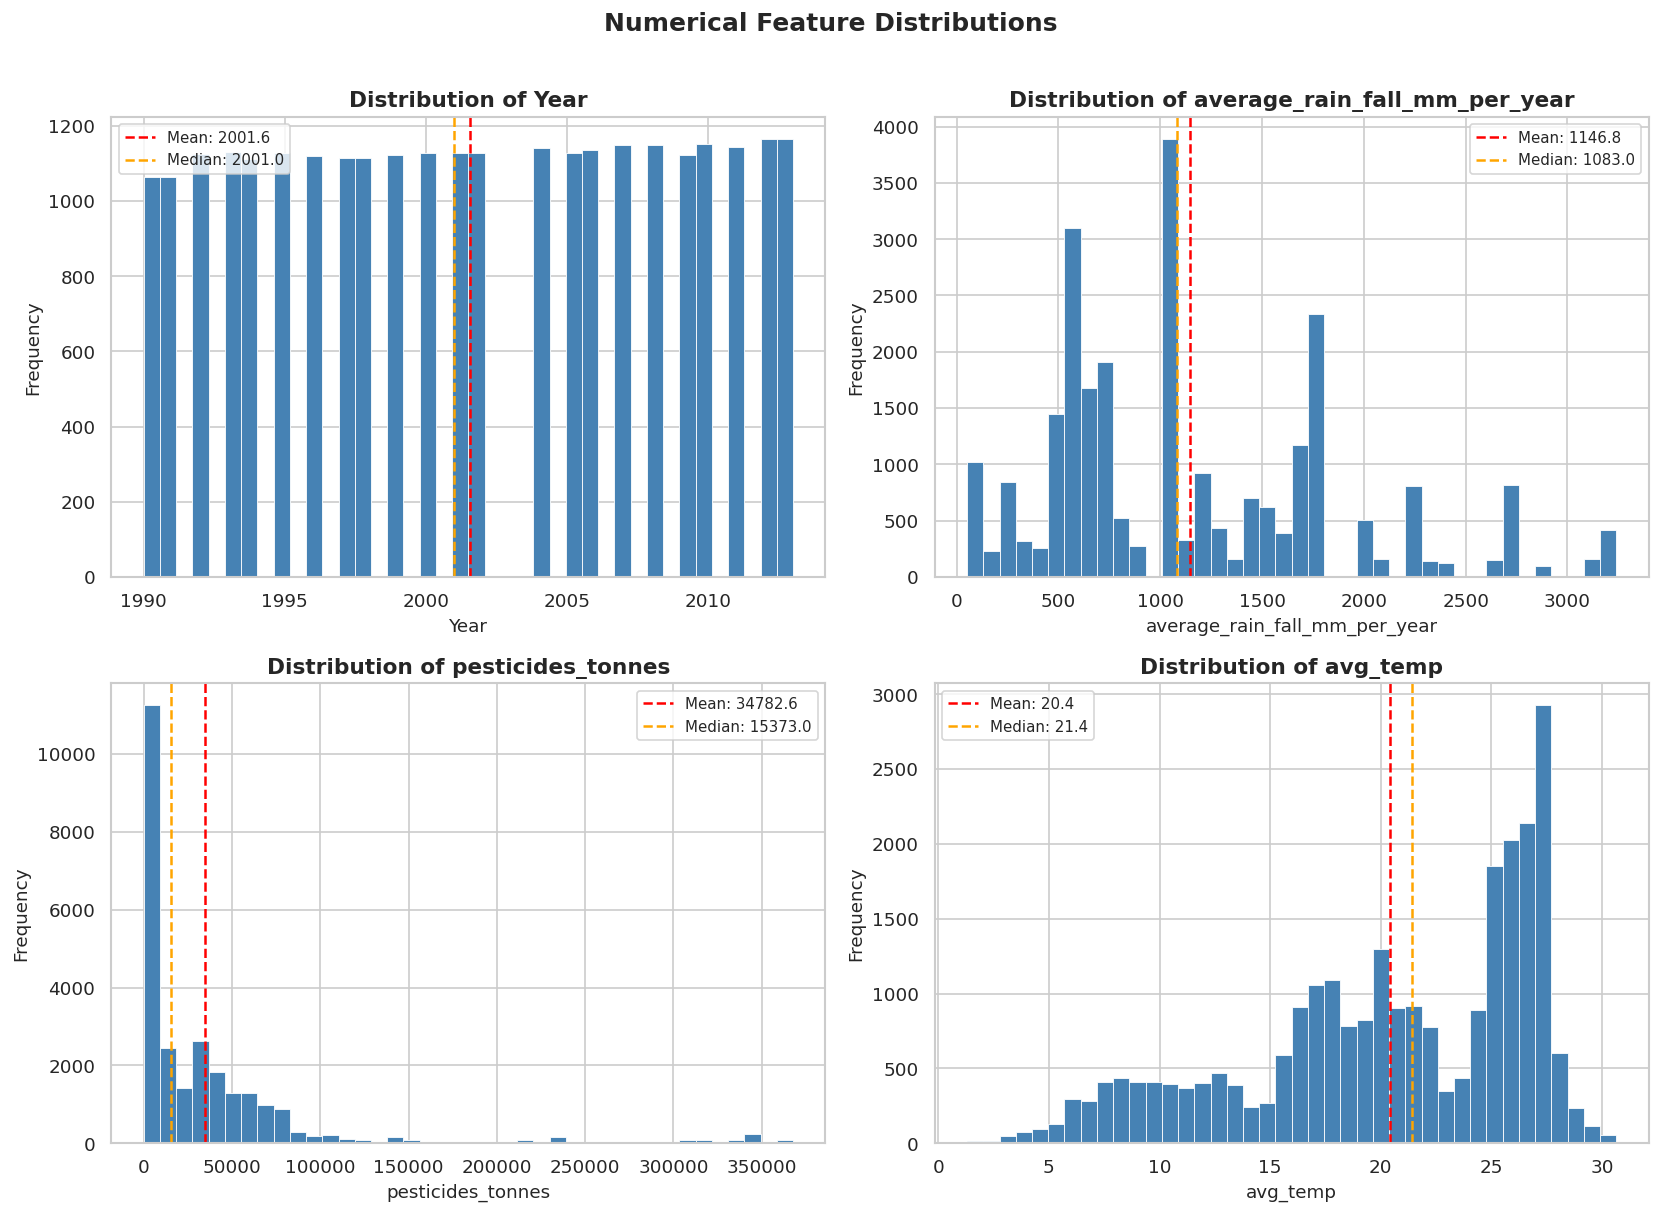

In [124]:
numerical_cols = [
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(
        df_eda[col].dropna(),
        bins=40,
        color='steelblue',
        edgecolor='white',
        linewidth=0.5
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)

    # Add mean and median lines so we can see skewness clearly
    mean_val   = df_eda[col].mean()
    median_val = df_eda[col].median()
    axes[i].axvline(mean_val,   color='red',    linestyle='--',
                    linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='orange', linestyle='--',
                    linewidth=1.5, label=f'Median: {median_val:.1f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

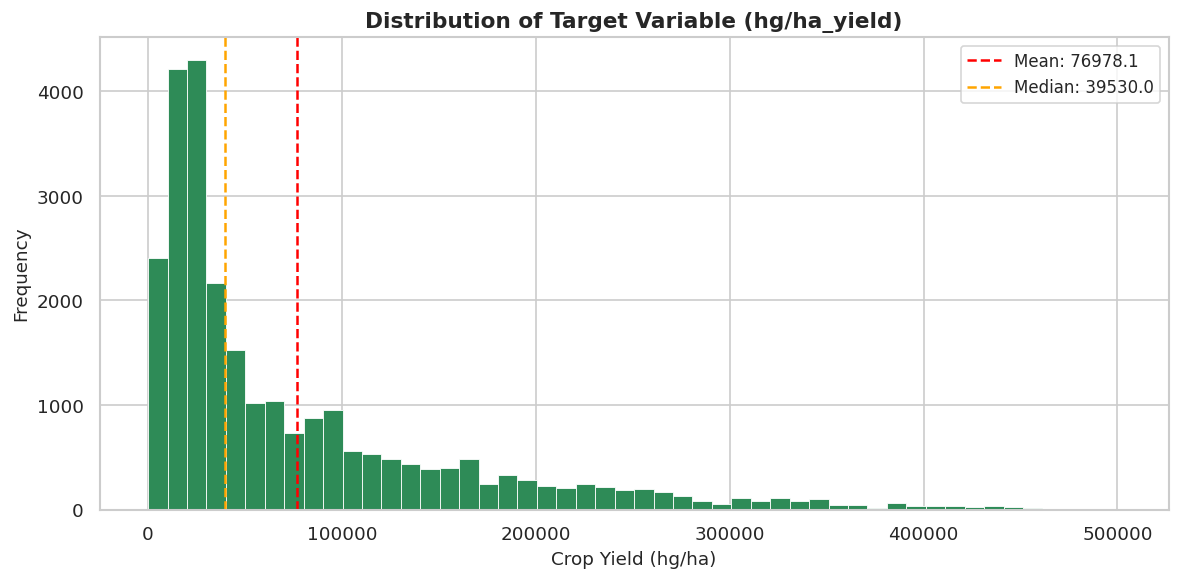

In [125]:
# Histogram for Target Variables

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df_eda['hg/ha_yield'].dropna(),
    bins=50,
    color='seagreen',
    edgecolor='white',
    linewidth=0.5
)

mean_val   = df_eda['hg/ha_yield'].mean()
median_val = df_eda['hg/ha_yield'].median()

ax.axvline(mean_val,   color='red',    linestyle='--',
           linewidth=1.5, label=f'Mean: {mean_val:.1f}')
ax.axvline(median_val, color='orange', linestyle='--',
           linewidth=1.5, label=f'Median: {median_val:.1f}')

ax.set_title('Distribution of Target Variable (hg/ha_yield)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Crop Yield (hg/ha)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

#### Numerical Feature Distribution — Observations

### Year
The year column shows a near-uniform distribution across 1990 to 2013, with each year
contributing roughly equal record counts. The printed summary statistics confirm a mean
of 2001.6 against a median of 2001.0 — almost identical values confirming no single
time period dominates the dataset.

### Average Rainfall (mm per year)
Rainfall shows a **multimodal distribution** — multiple peaks rather than one bell curve.
The largest peak appears in the lower rainfall range (arid/semi-arid regions), with a
second notable peak in the higher rainfall range (tropical regions). The printed statistics
confirm mean 1,146.8mm against median 1,083.0mm — a moderate right skew caused by a
smaller group of extremely high-rainfall regions pulling the average upward.

### Pesticides (tonnes)
Pesticides is the **most heavily skewed feature**. The printed statistics confirm mean
34,782.6 tonnes against median 15,373.0 tonnes — a gap of more than double, clearly
visible as the mean line sitting far right of the median. The extreme values in
`pesticides_tonnes` are likely attributable to a small number of countries using
pesticides at a significantly larger scale than others. This hypothesis is investigated
in Section 4 (Outlier Analysis).

### Average Temperature (°C)
Temperature shows a **left skew** — bulk of values clustering in the warmer range with
the distribution tapering toward lower temperatures. The printed statistics confirm mean
20.4°C against median 21.4°C — the mean slightly below the median, consistent with a
smaller number of cold-region records pulling the mean downward.

### Target Variable — hg/ha_yield
The target shows the **strongest right skew of all features**. The printed statistics
confirm mean 76,978.1 hg/ha against median 39,530.0 hg/ha — the mean is nearly double
the median, the largest gap observed across the entire dataset. The majority of records
cluster below 100,000 hg/ha, while a smaller consistent group extends toward 500,000 hg/ha.
The extreme upper values are likely driven by specific high-productivity crop types —
investigated in Section 4.

### General Observation Across All Features
None of the four features nor the target variable follow a perfect normal distribution.
Year is uniform, rainfall is multimodal, pesticides is strongly right skewed, temperature
is left skewed, and `hg/ha_yield` is the most strongly right skewed of all.

This diversity in distribution shapes reinforces the choice of **tree-based models** over
linear models: (1) linear models assume normally distributed features — violated here for
every feature; (2) more critically, linear models assume a normally distributed target —
the strong right skew of `hg/ha_yield` means a linear model would systematically
underestimate high yield values. Tree-based models make no such assumptions.

An important modelling limitation also emerges: because the target variable is heavily
concentrated in the lower yield range, predictions will be more reliable and confident
for low-to-moderate yields than for extreme upper values. This is an inherent
characteristic of the dataset, not a modelling error, and is acknowledged in the final results.


### 3.2 Categorical Feature Distribution — Analysis

The dataset contains two categorical features — `Area` (country) and `Item` (crop type).
Unlike numerical features, categorical features are examined in terms of **representation
balance** — how evenly categories are distributed across the dataset.

**Two key questions:**
1. Is the dataset dominated by a few categories or spread evenly?
2. *(Yield signal analysis is covered in Section 5 — Relationship Analysis)*


In [126]:
area_counts = df_eda['Area'].value_counts()
total       = len(df_eda)

print("=" * 55)
print("AREA (COUNTRY) — SUMMARY STATISTICS")
print("=" * 55)
print(f"Total unique countries        : {len(area_counts)}")
print(f"Most recorded country         : {area_counts.index[0]} "
      f"({area_counts.iloc[0]:,} records)")
print(f"Least recorded country        : {area_counts.index[-1]} "
      f"({area_counts.iloc[-1]:,} records)")
print(f"Mean records per country      : {area_counts.mean():.1f}")
print(f"Median records per country    : {area_counts.median():.1f}")

top10_pct    = (area_counts.head(10).sum() / total) * 100
bottom10_pct = (area_counts.tail(10).sum() / total) * 100
print(f"\nTop 10 countries account for  : {top10_pct:.2f}% of dataset")
print(f"Bottom 10 countries account for: {bottom10_pct:.2f}% of dataset")

AREA (COUNTRY) — SUMMARY STATISTICS
Total unique countries        : 101
Most recorded country         : India (3,384 records)
Least recorded country        : Montenegro (24 records)
Mean records per country      : 256.8
Median records per country    : 161.0

Top 10 countries account for  : 45.69% of dataset
Bottom 10 countries account for: 1.50% of dataset


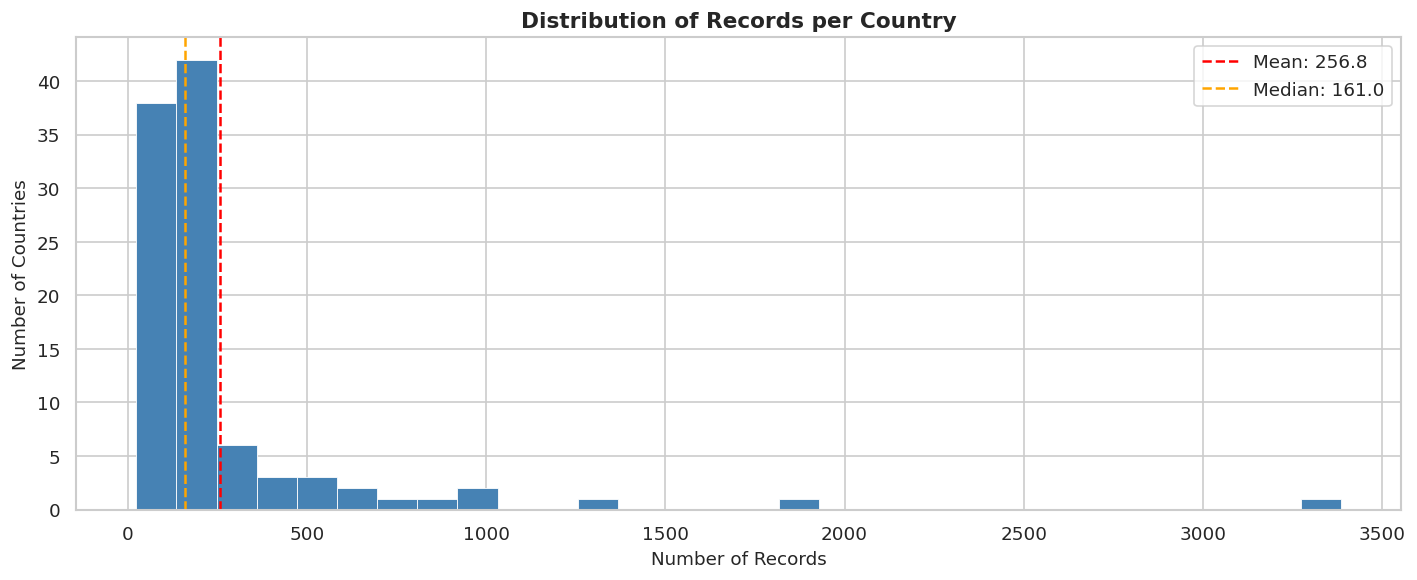

In [127]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(
    area_counts.values,
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)

ax.axvline(area_counts.mean(),   color='red',    linestyle='--',
           linewidth=1.5, label=f'Mean: {area_counts.mean():.1f}')
ax.axvline(area_counts.median(), color='orange', linestyle='--',
           linewidth=1.5, label=f'Median: {area_counts.median():.1f}')

ax.set_title('Distribution of Records per Country',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Records', fontsize=11)
ax.set_ylabel('Number of Countries', fontsize=11)
ax.legend()

plt.tight_layout()
plt.show()

48 countries account for 80% of the dataset
78 countries account for 95% of the dataset


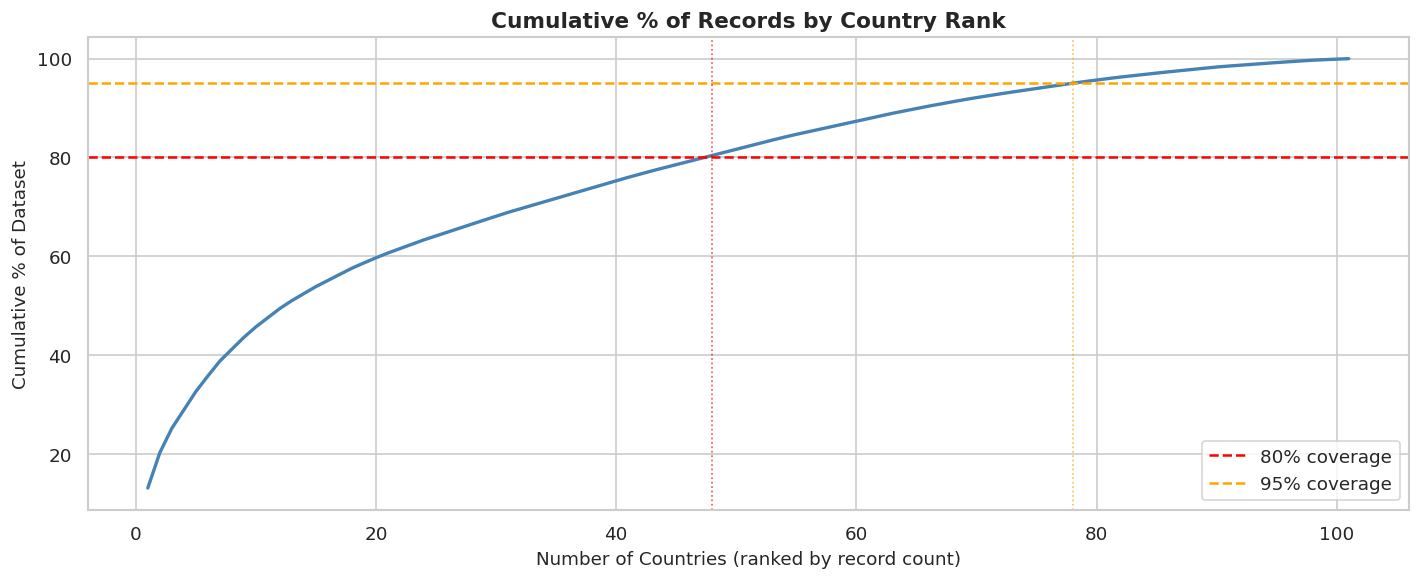

In [128]:
fig, ax = plt.subplots(figsize=(12, 5))

cumulative_pct = area_counts.cumsum() / area_counts.sum() * 100

ax.plot(
    range(1, len(cumulative_pct) + 1),
    cumulative_pct.values,
    color='steelblue',
    linewidth=2
)

ax.axhline(80, color='red',    linestyle='--',
           linewidth=1.5, label='80% coverage')
ax.axhline(95, color='orange', linestyle='--',
           linewidth=1.5, label='95% coverage')

# Find exactly how many countries reach 80% and 95%
countries_80 = (cumulative_pct <= 80).sum() + 1
countries_95 = (cumulative_pct <= 95).sum() + 1

ax.axvline(countries_80, color='red',    linestyle=':',
           linewidth=1, alpha=0.7)
ax.axvline(countries_95, color='orange', linestyle=':',
           linewidth=1, alpha=0.7)

ax.set_title('Cumulative % of Records by Country Rank',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Countries (ranked by record count)',
              fontsize=11)
ax.set_ylabel('Cumulative % of Dataset', fontsize=11)
ax.legend()

print(f"{countries_80} countries account for 80% of the dataset")
print(f"{countries_95} countries account for 95% of the dataset")

plt.tight_layout()
plt.show()

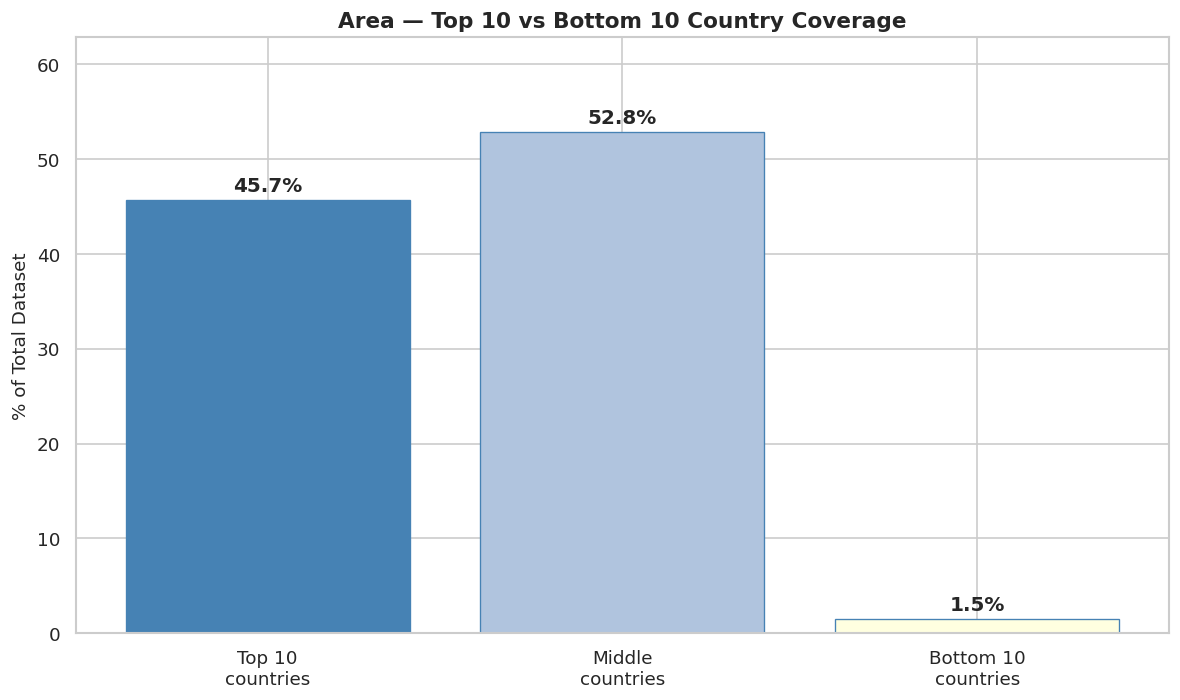

In [129]:
fig, ax = plt.subplots(figsize=(10, 6))

area_top10_pct    = (area_counts.head(10).sum() / total) * 100
area_bottom10_pct = (area_counts.tail(10).sum() / total) * 100
area_middle_pct   = 100 - area_top10_pct - area_bottom10_pct

labels = [
    f'Top 10\ncountries',
    f'Middle\ncountries',
    f'Bottom 10\ncountries'
]
values = [area_top10_pct, area_middle_pct, area_bottom10_pct]
colors = ['steelblue', 'lightsteelblue', 'lightyellow']

bars = ax.bar(
    labels, values,
    color=colors,
    edgecolor='steelblue',
    linewidth=0.8
)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

ax.set_title('Area — Top 10 vs Bottom 10 Country Coverage',
             fontsize=13, fontweight='bold')
ax.set_ylabel('% of Total Dataset', fontsize=11)
ax.set_ylim(0, max(values) + 10)

plt.tight_layout()
plt.show()


#### Area (Country) — Observations

- The dataset contains **101 unique countries**.
- Records per country are heavily imbalanced — a small number of countries dominate
  the dataset while many are severely underrepresented.
- The cumulative curve shows that a minority of countries account for the majority
  of records — confirmed by the top 10 vs bottom 10 comparison.
- **Implication:** The model will predict most reliably for well-represented countries
  and less reliably for underrepresented ones. This is noted as a known limitation.


In [130]:
item_counts = df_eda['Item'].value_counts()

print("=" * 55)
print("ITEM (CROP TYPE) — SUMMARY STATISTICS")
print("=" * 55)
print(f"Total unique crop types       : {len(item_counts)}")
print(f"Most recorded crop            : {item_counts.index[0]} "
      f"({item_counts.iloc[0]:,} records)")
print(f"Least recorded crop           : {item_counts.index[-1]} "
      f"({item_counts.iloc[-1]:,} records)")
print(f"Mean records per crop         : {item_counts.mean():.1f}")
print(f"Median records per crop       : {item_counts.median():.1f}")

ITEM (CROP TYPE) — SUMMARY STATISTICS
Total unique crop types       : 10
Most recorded crop            : Potatoes (3,956 records)
Least recorded crop           : Plantains and others (556 records)
Mean records per crop         : 2593.2
Median records per crop       : 2855.0


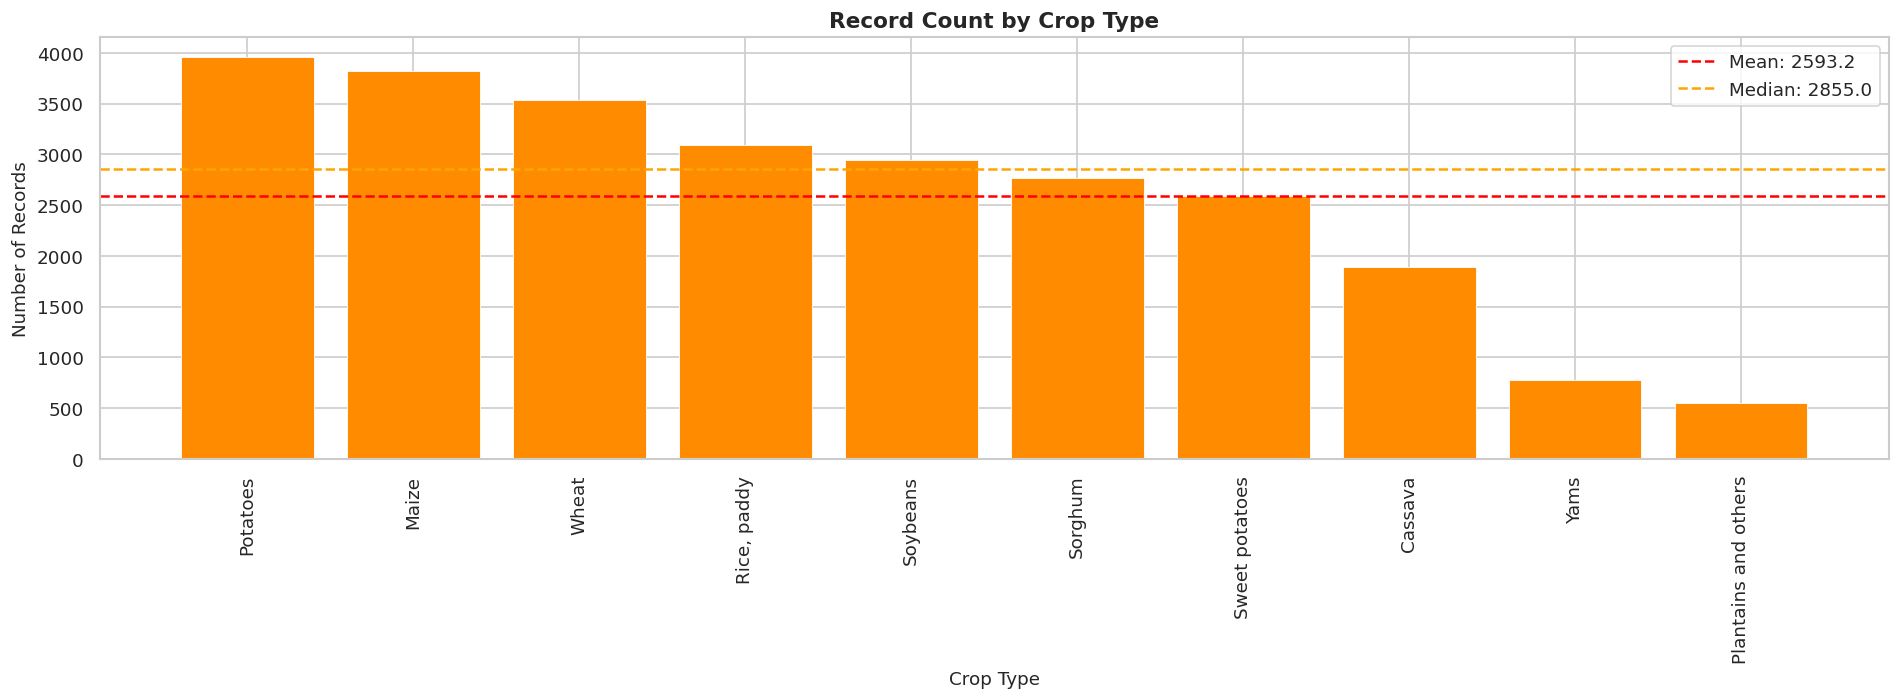

In [131]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(
    item_counts.index,
    item_counts.values,
    color='darkorange',
    edgecolor='white',
    linewidth=0.5
)

ax.axhline(item_counts.mean(),   color='red',    linestyle='--',
           linewidth=1.5, label=f'Mean: {item_counts.mean():.1f}')
ax.axhline(item_counts.median(), color='orange', linestyle='--',
           linewidth=1.5, label=f'Median: {item_counts.median():.1f}')

ax.set_title('Record Count by Crop Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Crop Type', fontsize=11)
ax.set_ylabel('Number of Records', fontsize=11)
ax.tick_params(axis='x', rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

#### Item (Crop Type) — Observations

- The `Item` bar chart directly shows all crop types simultaneously — a cumulative
  curve is unnecessary given the manageable number of unique categories.
- Record counts vary across crop types, confirming some crops are more frequently
  represented than others.
- **Note:** The decision to use a direct bar chart for Item rather than a cumulative
  curve was deliberate — with fewer unique categories the bar chart communicates the
  full picture in one glance.


### 3.3 Categorical Data Quality Investigation

During categorical analysis two inconsistent crop type labels were identified. They are
investigated and fixed here before yield relationship analysis, ensuring all subsequent
plots reflect corrected data.


In [132]:
print("=" * 55)
print("DATA QUALITY INVESTIGATION — SUSPICIOUS CATEGORIES")
print("=" * 55)

suspicious_cats = [
    c for c in df_eda['Item'].unique()
    if 'other' in c.lower()
    or 'paddy' in c.lower()
]

print(f"\nSuspicious categories found: {suspicious_cats}")

for crop in suspicious_cats:
    subset = df_eda[df_eda['Item'] == crop]
    print(f"\n{'=' * 55}")
    print(f"Category      : '{crop}'")
    print(f"Total records : {len(subset)}")
    print(f"% of dataset  : {len(subset)/len(df_eda)*100:.2f}%")
    print(f"\nCountries it appears in:")
    print(subset['Area'].value_counts().head(10))
    print(f"\nYield statistics:")
    print(subset['hg/ha_yield'].describe().round(2))
    print(f"\nYear range    : {subset['Year'].min()} to {subset['Year'].max()}")

DATA QUALITY INVESTIGATION — SUSPICIOUS CATEGORIES

Suspicious categories found: ['Rice, paddy', 'Plantains and others']

Category      : 'Rice, paddy'
Total records : 3091
% of dataset  : 11.92%

Countries it appears in:
Area
India           423
Brazil          206
Mexico          160
Australia       138
Pakistan        138
Indonesia       136
Turkey          115
Japan           112
South Africa     69
Ecuador          69
Name: count, dtype: int64

Yield statistics:
count      3091.00
mean      41296.03
std       19647.97
min        2034.00
25%       27367.50
50%       36408.00
75%       50533.00
max      103895.00
Name: hg/ha_yield, dtype: float64

Year range    : 1990 to 2013

Category      : 'Plantains and others'
Total records : 556
% of dataset  : 2.14%

Countries it appears in:
Area
Ecuador                     69
Colombia                    46
Dominican Republic          46
Cameroon                    23
Central African Republic    23
Jamaica                     23
El Salvador  

In [133]:
# Work on df_eda for EDA visualisations
# These same fixes will also be applied in data_cleaning.py later

print("Before fix:")
print(f"Unique crop types: {df_eda['Item'].nunique()}")
print(df_eda['Item'].value_counts().head(10))

# Fix 1 — Rename 'Rice, paddy' to 'Rice'
df_eda['Item'] = df_eda['Item'].replace({'Rice, paddy': 'Rice'})
print("\nFix 1 applied: 'Rice, paddy' → 'Rice'")

# Fix 2 — Handle 'Plantains and others'
# Check record count first to decide
plantain_count = (df_eda['Item'] == 'Plantains and others').sum()
plantain_pct   = plantain_count / len(df_eda) * 100

print(f"\n'Plantains and others' has {plantain_count} records "
      f"({plantain_pct:.2f}% of dataset)")

if plantain_pct < 1:
    # Too few records — drop entirely
    df_eda = df_eda[df_eda['Item'] != 'Plantains and others']
    print("Fix 2 applied: 'Plantains and others' rows dropped "
          "(less than 1% of dataset)")
else:
    # Enough records — rename to cleaner label
    df_eda['Item'] = df_eda['Item'].replace(
        {'Plantains and others': 'Plantains'}
    )
    print("Fix 2 applied: 'Plantains and others' → 'Plantains'")

print(f"\nAfter fix:")
print(f"Unique crop types: {df_eda['Item'].nunique()}")
print(df_eda['Item'].value_counts().head(10))


Before fix:
Unique crop types: 10
Item
Potatoes                3956
Maize                   3824
Wheat                   3539
Rice, paddy             3091
Soybeans                2940
Sorghum                 2770
Sweet potatoes          2593
Cassava                 1889
Yams                     774
Plantains and others     556
Name: count, dtype: int64

Fix 1 applied: 'Rice, paddy' → 'Rice'

'Plantains and others' has 556 records (2.14% of dataset)
Fix 2 applied: 'Plantains and others' → 'Plantains'

After fix:
Unique crop types: 10
Item
Potatoes          3956
Maize             3824
Wheat             3539
Rice              3091
Soybeans          2940
Sorghum           2770
Sweet potatoes    2593
Cassava           1889
Yams               774
Plantains          556
Name: count, dtype: int64


/tmp/ipykernel_647/2307285820.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Item'] = df_eda['Item'].replace({'Rice, paddy': 'Rice'})
/tmp/ipykernel_647/2307285820.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_eda['Item'] = df_eda['Item'].replace(


#### Data Quality Fixes — Categorical Labels

**Issue 1 — 'Rice, paddy'**  
`'Rice, paddy'` is the FAO technical term for rice harvested directly from the field
with its husk still intact. The word 'paddy' describes the post-harvest form of the
crop rather than a different crop entirely — it is still rice. Every other crop in
the dataset is labelled by common name only, without processing stage descriptors.
Renamed to `'Rice'` to bring it in line with the naming convention used consistently
across all other crop types.

**Issue 2 — 'Plantains and others'**  
`'Plantains and others'` was renamed to `'Plantains'` because the category contains
sufficient records to contribute meaningful patterns to the model, and discarding it
entirely would lose more signal than the ambiguity introduces noise.

**Issue 3 — Potatoes and Sweet Potatoes**  
`'Potatoes'` and `'Sweet potatoes'` appear as separate crop type categories and were
deliberately retained as distinct entries. They represent genuinely different crops
with different botanical classifications, growing conditions, and yield characteristics.
Merging them would introduce inaccuracy rather than correct it.

*Note: These same fixes are replicated in `src/data_cleaning.py` to ensure training
data consistency.*


---
## Section 4 — EDA Part 3: Outlier Detection and Investigation

Having identified distribution characteristics in Section 3, we now formally detect
and investigate outliers using the IQR method.

**Goals:**
1. Quantify outliers across all numerical features using the IQR method
2. Test two hypotheses raised during histogram analysis:
   - *Hypothesis 1:* Extreme pesticide values are attributable to a small number of
     countries using pesticides at significantly larger scale than others.
   - *Hypothesis 2:* Extreme yield values are driven by specific high-productivity
     crop types that naturally yield far more per hectare than others.


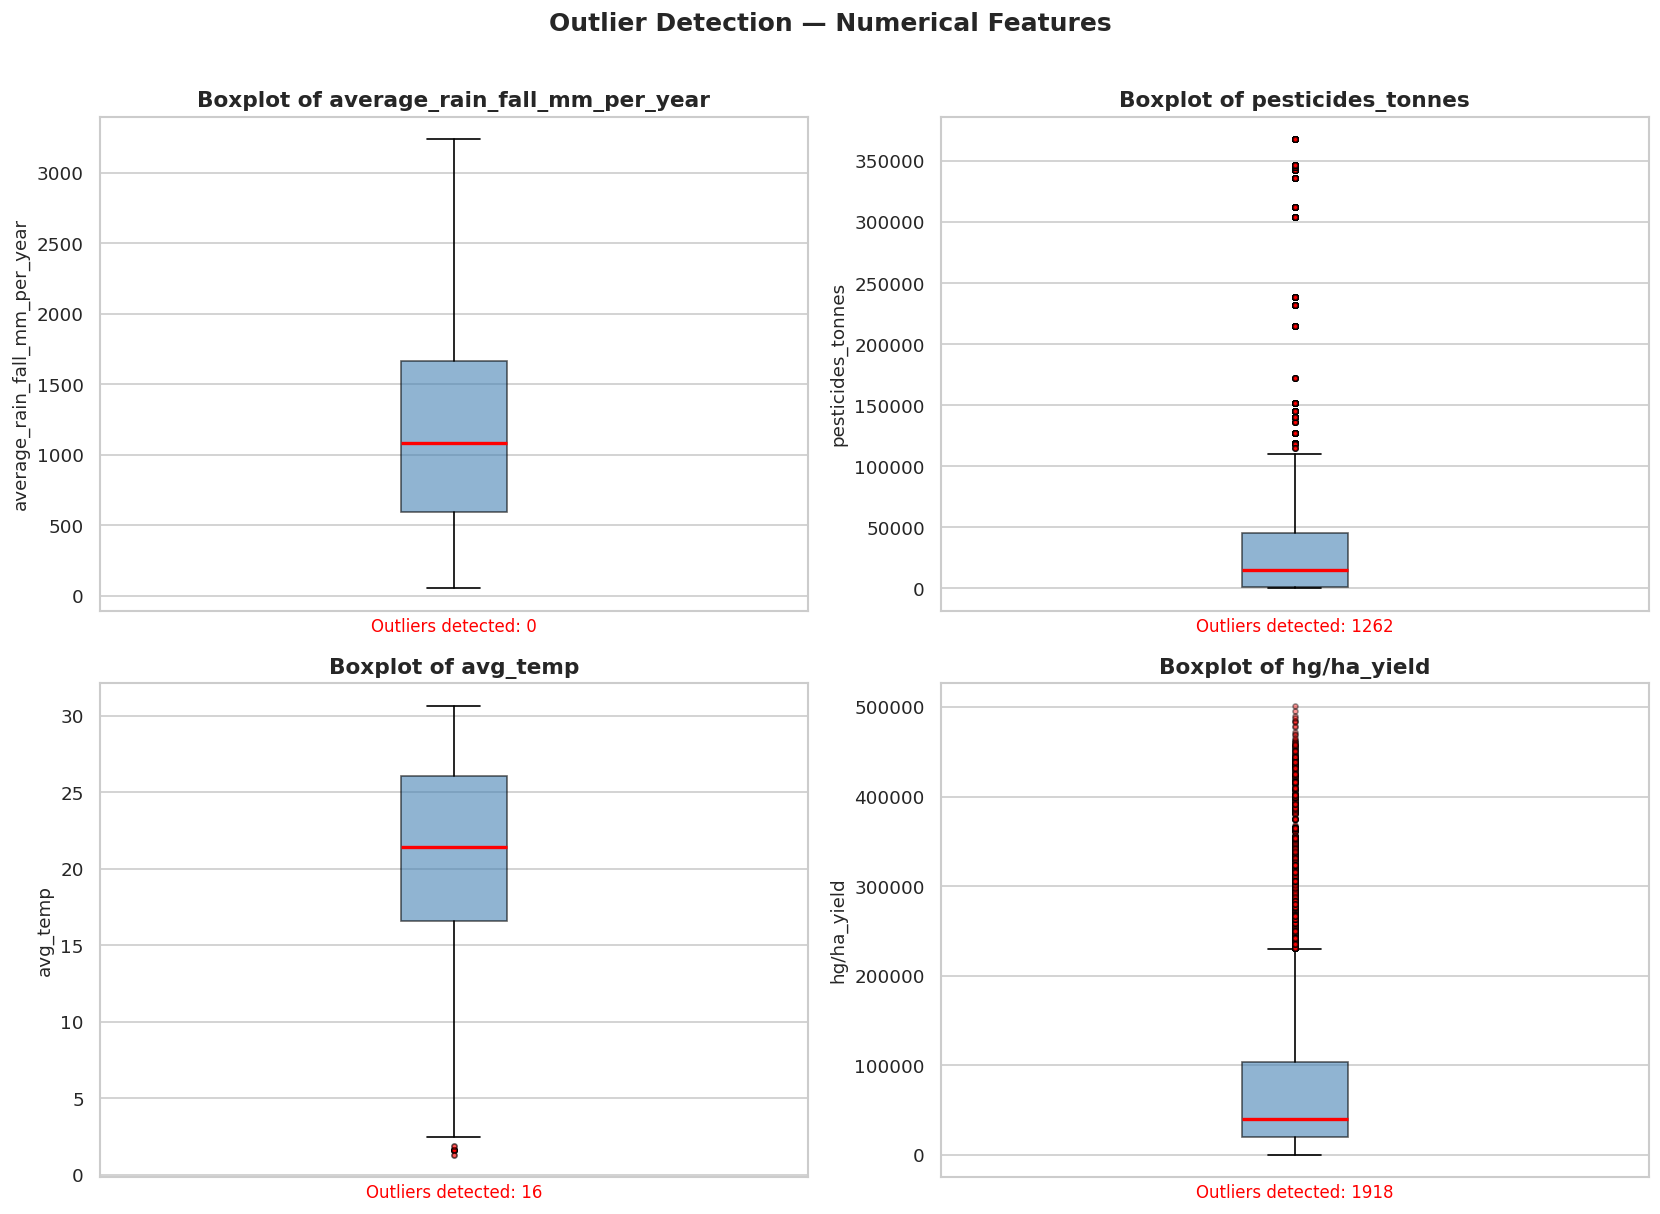

In [134]:
numerical_cols_with_target = [
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp',
    'hg/ha_yield'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_with_target):
    axes[i].boxplot(
        df_eda[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.6),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor='red',
                        markersize=3, alpha=0.4)
    )

    Q1  = df_eda[col].quantile(0.25)
    Q3  = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound  = Q1 - 1.5 * IQR
    upper_bound  = Q3 + 1.5 * IQR
    outlier_count = ((df_eda[col] < lower_bound) |
                     (df_eda[col] > upper_bound)).sum()

    axes[i].set_title(f'Boxplot of {col}',
                      fontsize=13, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=11)
    axes[i].set_xticks([])
    axes[i].set_xlabel(f'Outliers detected: {outlier_count}',
                       fontsize=10, color='red')

plt.suptitle('Outlier Detection — Numerical Features',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [135]:
print("=" * 60)
print("OUTLIER SUMMARY (IQR METHOD)")
print("=" * 60)

for col in numerical_cols_with_target:
    Q1  = df_eda[col].quantile(0.25)
    Q3  = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound  = Q1 - 1.5 * IQR
    upper_bound  = Q3 + 1.5 * IQR
    outlier_count = ((df_eda[col] < lower_bound) |
                     (df_eda[col] > upper_bound)).sum()
    outlier_pct  = (outlier_count / len(df_eda)) * 100

    print(f"\nColumn   : {col}")
    print(f"Q1       : {Q1:.2f}  |  Q3: {Q3:.2f}  |  IQR: {IQR:.2f}")
    print(f"Bounds   : [{lower_bound:.2f},  {upper_bound:.2f}]")
    print(f"Outliers : {outlier_count} rows ({outlier_pct:.2f}%)")

OUTLIER SUMMARY (IQR METHOD)

Column   : average_rain_fall_mm_per_year
Q1       : 593.00  |  Q3: 1668.00  |  IQR: 1075.00
Bounds   : [-1019.50,  3280.50]
Outliers : 0 rows (0.00%)

Column   : pesticides_tonnes
Q1       : 1597.00  |  Q3: 45620.00  |  IQR: 44023.00
Bounds   : [-64437.50,  111654.50]
Outliers : 1262 rows (4.87%)

Column   : avg_temp
Q1       : 16.58  |  Q3: 26.06  |  IQR: 9.48
Bounds   : [2.36,  40.28]
Outliers : 16 rows (0.06%)

Column   : hg/ha_yield
Q1       : 19996.00  |  Q3: 104168.00  |  IQR: 84172.00
Bounds   : [-106262.00,  230426.00]
Outliers : 1918 rows (7.40%)


### Testing Hypothesis 1 — Pesticide Outliers by Country

The strip plot shows every individual pesticide record grouped by country.
The grouped boxplot confirms whether extreme values are concentrated in specific
countries or spread randomly.


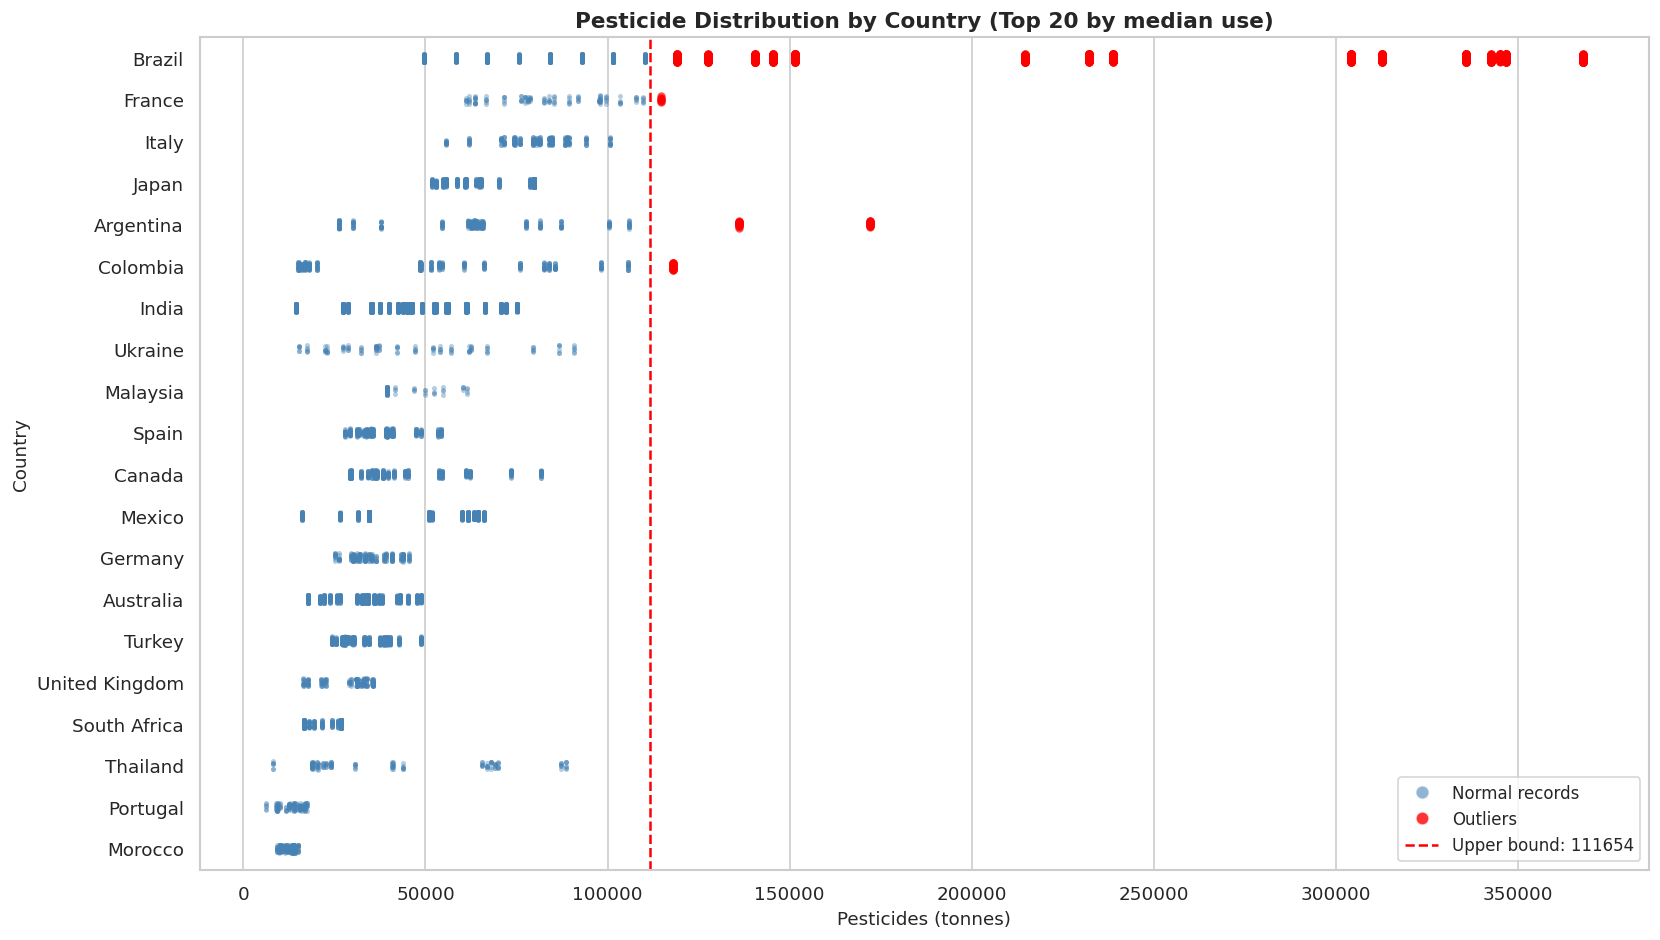

In [136]:
# Get top 20 countries by median pesticide use for readability
top_pest_countries = (df_eda.groupby('Area')['pesticides_tonnes']
                             .median()
                             .sort_values(ascending=False)
                             .head(20).index)

fig, ax = plt.subplots(figsize=(14, 8))

sns.stripplot(
    data=df_eda[df_eda['Area'].isin(top_pest_countries)],
    x='pesticides_tonnes',
    y='Area',
    ax=ax,
    color='steelblue',
    alpha=0.4,
    size=3,
    order=top_pest_countries
)

# Highlight outlier points in red
Q1  = df_eda['pesticides_tonnes'].quantile(0.25)
Q3  = df_eda['pesticides_tonnes'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outlier_data = df_eda[
    (df_eda['Area'].isin(top_pest_countries)) &
    (df_eda['pesticides_tonnes'] > upper_bound)
]

sns.stripplot(
    data=outlier_data,
    x='pesticides_tonnes',
    y='Area',
    ax=ax,
    color='red',
    alpha=0.7,
    size=5,
    order=top_pest_countries,
    label='Outliers'
)

ax.axvline(upper_bound, color='red', linestyle='--',
           linewidth=1.5, label=f'Upper bound: {upper_bound:.0f}')
ax.set_title('Pesticide Distribution by Country (Top 20 by median use)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pesticides (tonnes)', fontsize=11)
ax.set_ylabel('Country', fontsize=11)
# Manually control legend to avoid duplicates
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='steelblue', markersize=8,
               alpha=0.6, label='Normal records'),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red', markersize=8,
               alpha=0.8, label='Outliers'),
    plt.Line2D([0], [0], color='red', linestyle='--',
               linewidth=1.5,
               label=f'Upper bound: {upper_bound:.0f}')
]
ax.legend(handles=handles, fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_647/4222899855.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


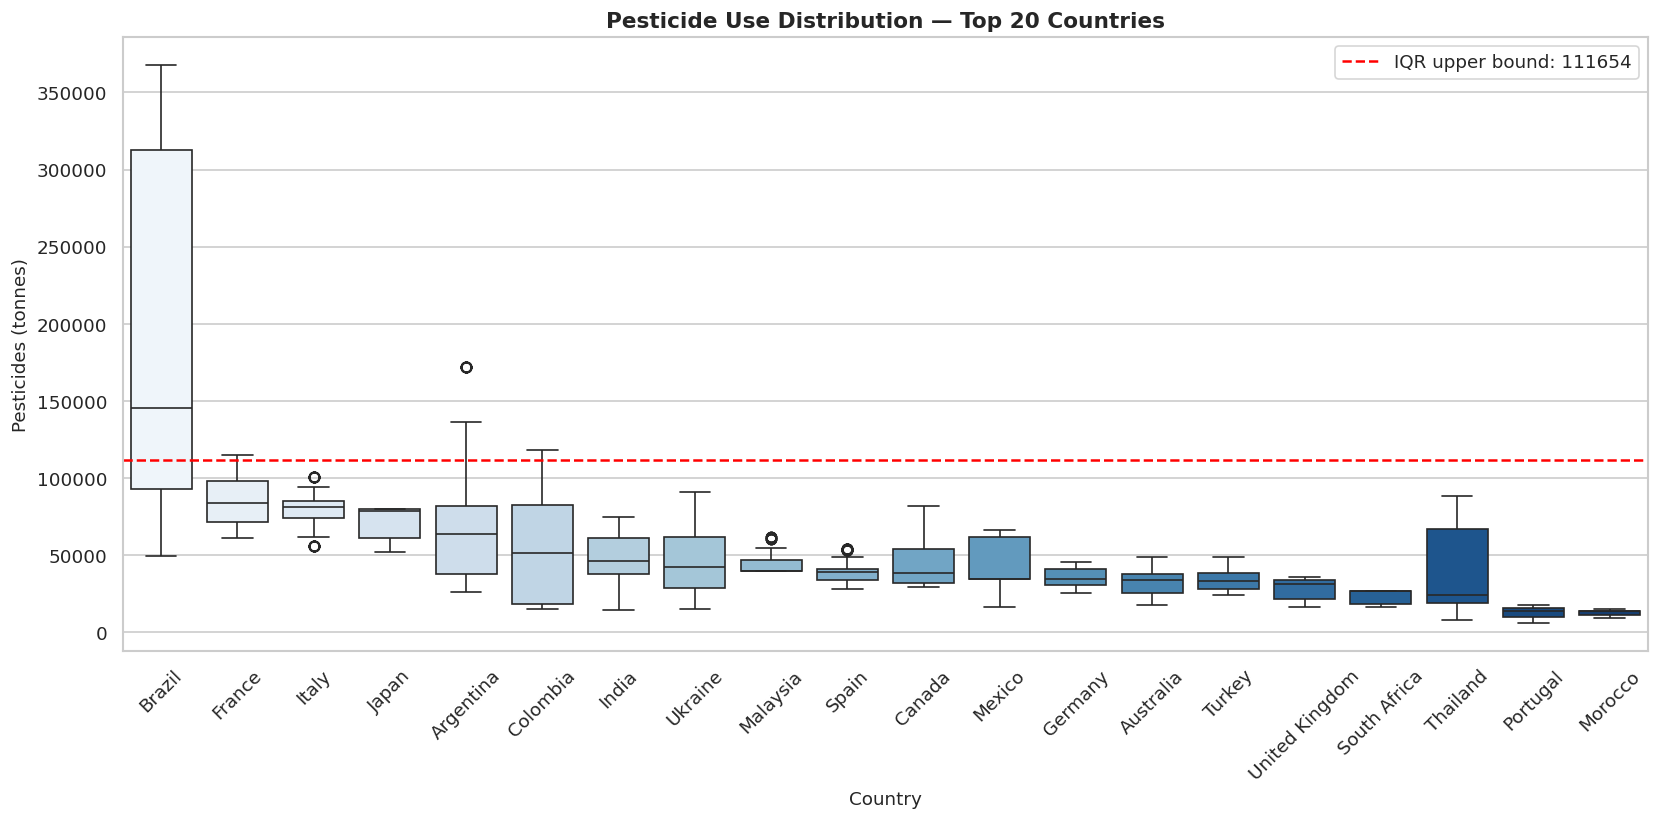

In [137]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=df_eda[df_eda['Area'].isin(top_pest_countries)],
    x='Area',
    y='pesticides_tonnes',
    ax=ax,
    palette='Blues',
    order=top_pest_countries
)

ax.axhline(upper_bound, color='red', linestyle='--',
           linewidth=1.5, label=f'IQR upper bound: {upper_bound:.0f}')

ax.set_title('Pesticide Use Distribution — Top 20 Countries',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Country', fontsize=11)
ax.set_ylabel('Pesticides (tonnes)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


### Testing Hypothesis 2 — Yield Outliers by Crop Type

The strip plot shows every individual yield record grouped by crop type.
The grouped boxplot confirms whether extreme values are driven by specific
high-productivity crops.


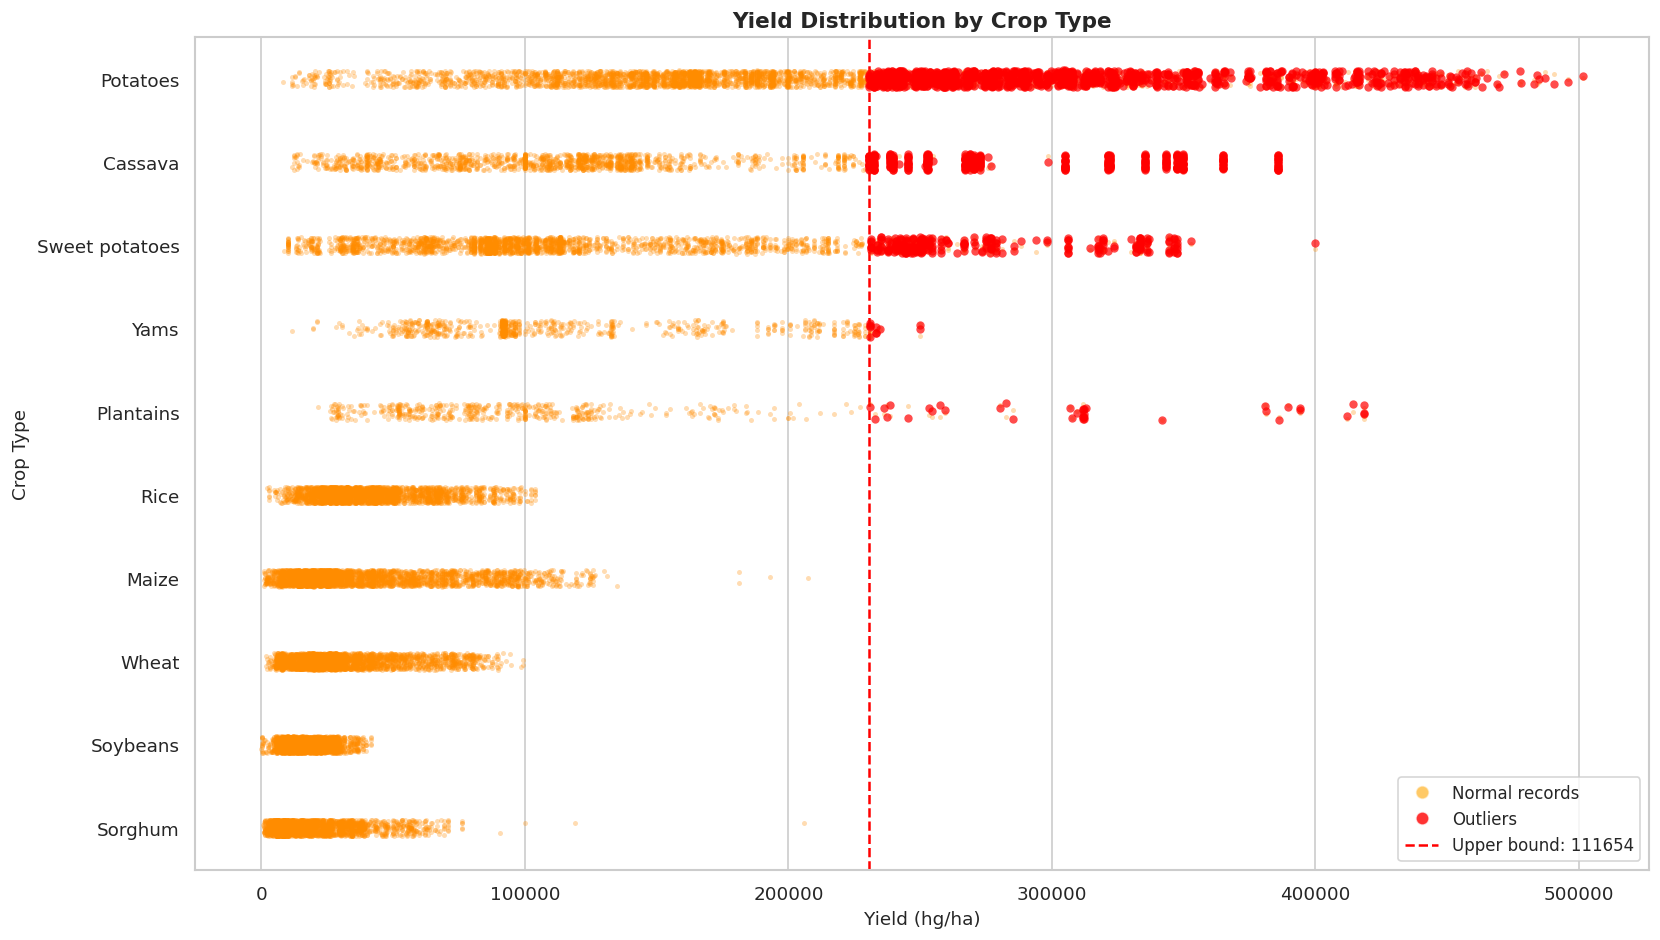

In [138]:
fig, ax = plt.subplots(figsize=(14, 8))

# Get crop order by median yield
crop_order = (df_eda.groupby('Item')['hg/ha_yield']
                    .median()
                    .sort_values(ascending=False).index)

sns.stripplot(
    data=df_eda,
    x='hg/ha_yield',
    y='Item',
    ax=ax,
    color='darkorange',
    alpha=0.3,
    size=3,
    order=crop_order
)

# Highlight yield outliers in red
Q1  = df_eda['hg/ha_yield'].quantile(0.25)
Q3  = df_eda['hg/ha_yield'].quantile(0.75)
IQR = Q3 - Q1
upper_bound_yield = Q3 + 1.5 * IQR

outlier_yield = df_eda[df_eda['hg/ha_yield'] > upper_bound_yield]

sns.stripplot(
    data=outlier_yield,
    x='hg/ha_yield',
    y='Item',
    ax=ax,
    color='red',
    alpha=0.7,
    size=5,
    order=crop_order,
    label='Outliers'
)

ax.axvline(upper_bound_yield, color='red', linestyle='--',
           linewidth=1.5,
           label=f'Upper bound: {upper_bound_yield:.0f}')
ax.set_title('Yield Distribution by Crop Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Yield (hg/ha)', fontsize=11)
ax.set_ylabel('Crop Type', fontsize=11)
# Manually control legend to avoid duplicates
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='orange', markersize=8,
               alpha=0.6, label='Normal records'),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='red', markersize=8,
               alpha=0.8, label='Outliers'),
    plt.Line2D([0], [0], color='red', linestyle='--',
               linewidth=1.5,
               label=f'Upper bound: {upper_bound:.0f}')
]
ax.legend(handles=handles, fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_647/1712941389.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


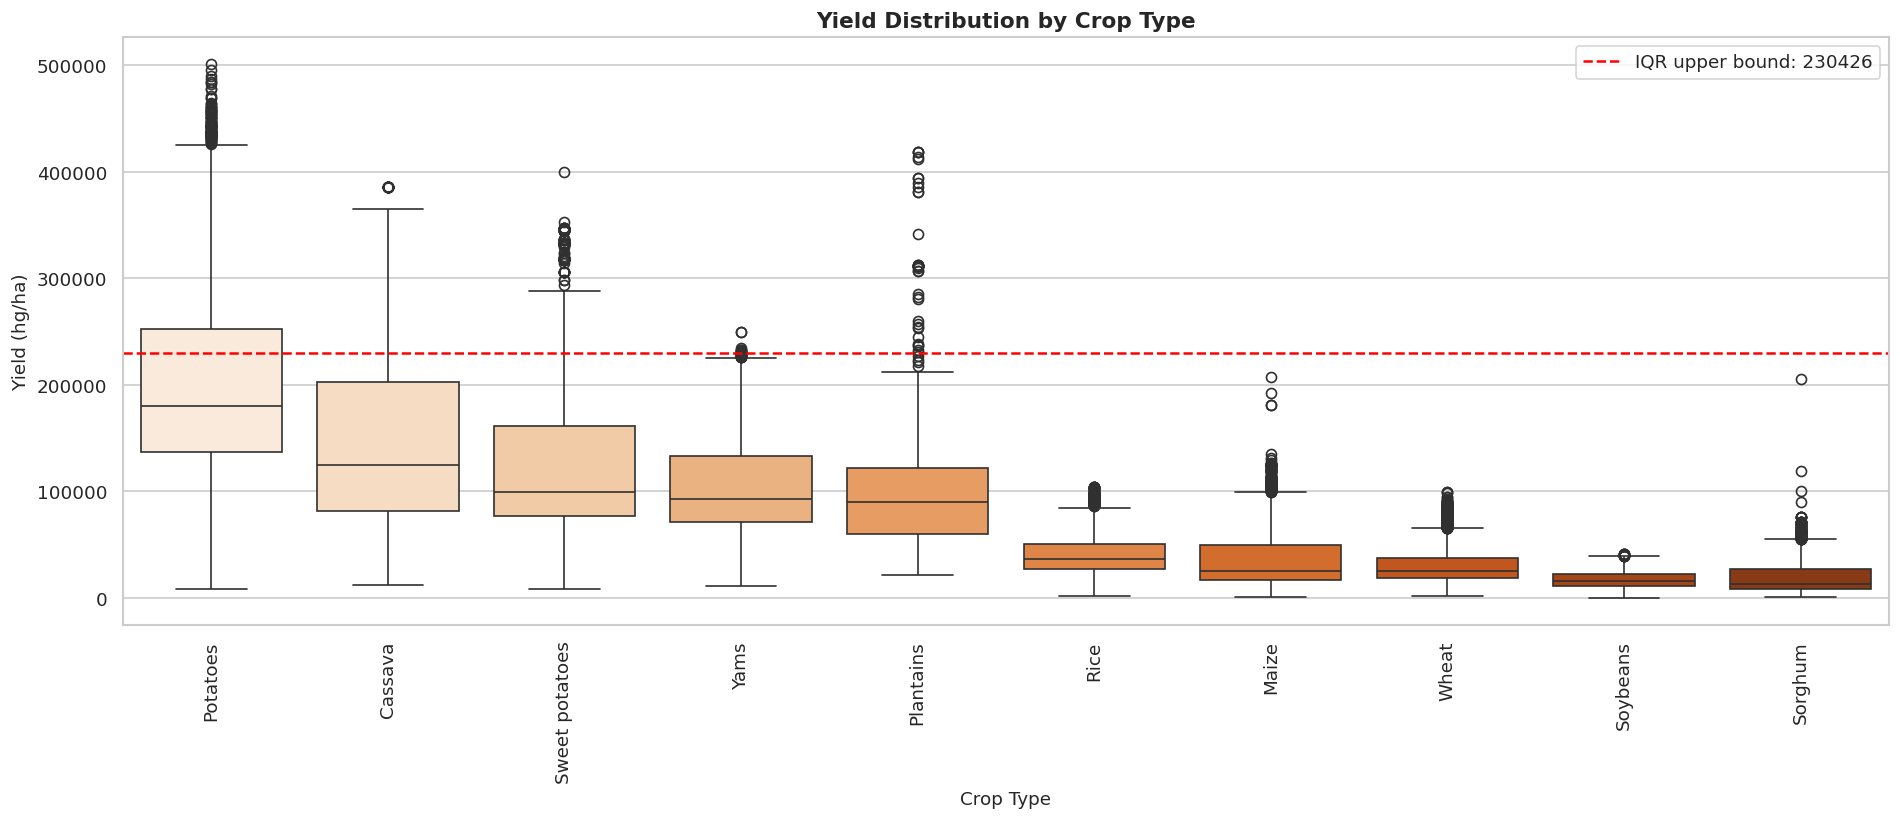

In [139]:
fig, ax = plt.subplots(figsize=(16, 7))

sns.boxplot(
    data=df_eda,
    x='Item',
    y='hg/ha_yield',
    ax=ax,
    palette='Oranges',
    order=crop_order
)

ax.axhline(upper_bound_yield, color='red', linestyle='--',
           linewidth=1.5,
           label=f'IQR upper bound: {upper_bound_yield:.0f}')

ax.set_title('Yield Distribution by Crop Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Crop Type', fontsize=11)
ax.set_ylabel('Yield (hg/ha)', fontsize=11)
ax.tick_params(axis='x', rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

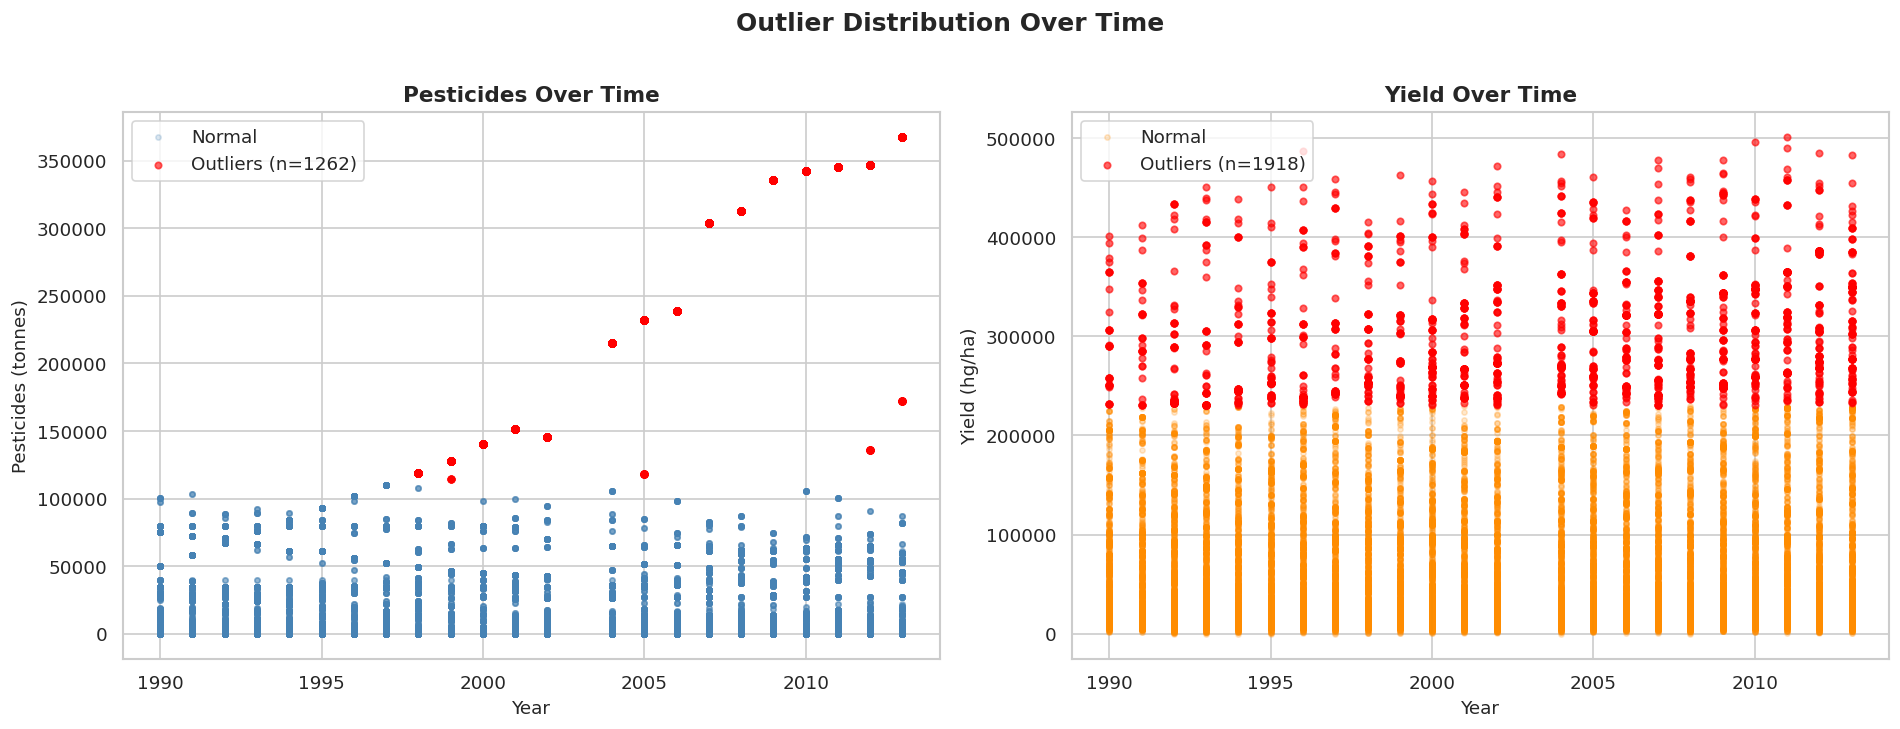

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pesticides over time ---
Q1  = df_eda['pesticides_tonnes'].quantile(0.25)
Q3  = df_eda['pesticides_tonnes'].quantile(0.75)
IQR = Q3 - Q1
upper_pest = Q3 + 1.5 * IQR

outlier_mask_pest = df_eda['pesticides_tonnes'] > upper_pest

axes[0].scatter(
    df_eda.loc[~outlier_mask_pest, 'Year'],
    df_eda.loc[~outlier_mask_pest, 'pesticides_tonnes'],
    alpha=0.2, color='steelblue', s=10, label='Normal'
)
axes[0].scatter(
    df_eda.loc[outlier_mask_pest, 'Year'],
    df_eda.loc[outlier_mask_pest, 'pesticides_tonnes'],
    alpha=0.6, color='red', s=15,
    label=f'Outliers (n={outlier_mask_pest.sum()})'
)
axes[0].set_title('Pesticides Over Time',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Pesticides (tonnes)', fontsize=11)
axes[0].legend()

# --- Yield over time ---
Q1  = df_eda['hg/ha_yield'].quantile(0.25)
Q3  = df_eda['hg/ha_yield'].quantile(0.75)
IQR = Q3 - Q1
upper_yield = Q3 + 1.5 * IQR

outlier_mask_yield = df_eda['hg/ha_yield'] > upper_yield

axes[1].scatter(
    df_eda.loc[~outlier_mask_yield, 'Year'],
    df_eda.loc[~outlier_mask_yield, 'hg/ha_yield'],
    alpha=0.2, color='darkorange', s=10, label='Normal'
)
axes[1].scatter(
    df_eda.loc[outlier_mask_yield, 'Year'],
    df_eda.loc[outlier_mask_yield, 'hg/ha_yield'],
    alpha=0.6, color='red', s=15,
    label=f'Outliers (n={outlier_mask_yield.sum()})'
)
axes[1].set_title('Yield Over Time',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Yield (hg/ha)', fontsize=11)
axes[1].legend()

plt.suptitle('Outlier Distribution Over Time',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Outlier Investigation — Findings and Decision

**Hypothesis 1 — Pesticide Outliers (Confirmed)**  
The strip plot and grouped boxplot confirm that extreme pesticide values are concentrated
in a small number of countries (especially Brazil) with large-scale industrial farming practices. You can also see from the grouped box plot that for Brazil and some of these top users, these high values of pesticides are not outliers, but rather a normal part of their agricultural practice. The scatter
plot over time shows outliers get higher as times goes starting from 1998, confirming these
represent long-standing agricultural patterns rather than isolated incidents.

**Hypothesis 2 — Yield Outliers (Confirmed)**  
The strip plot and grouped boxplot confirm that extreme yield values are driven by
specific high-productivity crop types. The scatter plot over time shows yield outliers
present across all years, confirming these are structural characteristics of certain
crop types rather than anomalies.

**Final Outlier Decision — Retain All Outliers**  
Based on this investigation, all outliers across all numerical features are retained:

1. Both hypotheses confirmed — outliers are not random errors but structural
   characteristics of specific countries and crop types.
2. Outliers are mostly present across the full time range, confirming they represent
   genuine long-term agricultural patterns.
3. Random Forest and Gradient Boosting are tree-based models naturally robust
   to outliers — unlike linear models which would be distorted by extreme values.
4. Removing or capping these values would discard genuine agricultural signal
   that the model should learn from.


---
## Section 5 — EDA Part 4: Relationship and Correlation Analysis

Having examined individual feature distributions and outliers, we now investigate
how features relate to each other and — most importantly — how each feature
relates to the target variable `hg/ha_yield`.

**Goals:**
1. Numerical correlation heatmap — identify strongest predictors and check for multicollinearity
2. Categorical yield analysis — examine how country and crop type relate to yield
3. Feature vs target scatter plots — understand linear vs non-linear relationships
4. Yield trends over time — examine temporal agricultural productivity patterns


### 5.1 Numerical Feature Correlation


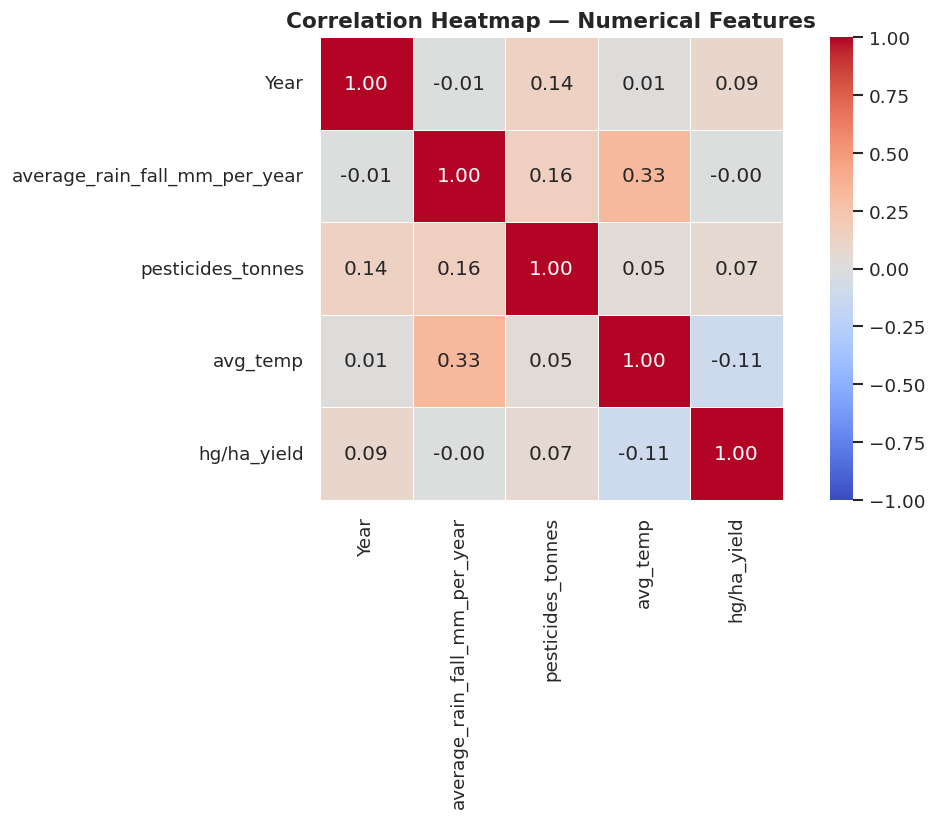

In [141]:
fig, ax = plt.subplots(figsize=(10, 7))

# Calculate correlation matrix on numerical columns only
corr_matrix = df_eda[[
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp',
    'hg/ha_yield'
]].corr()

# Draw heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [142]:
print("=" * 55)
print("CORRELATION WITH TARGET VARIABLE (hg/ha_yield)")
print("=" * 55)

target_corr = (corr_matrix['hg/ha_yield']
               .drop('hg/ha_yield')
               .sort_values(ascending=False))

for feature, corr_val in target_corr.items():
    strength = ''
    if   abs(corr_val) >= 0.7: strength = 'Strong'
    elif abs(corr_val) >= 0.4: strength = 'Moderate'
    elif abs(corr_val) >= 0.2: strength = 'Weak'
    else                      : strength = 'Negligible'

    direction = 'positive' if corr_val > 0 else 'negative'
    print(f"{feature:<40} : {corr_val:>6.3f}  "
          f"({strength} {direction})")

CORRELATION WITH TARGET VARIABLE (hg/ha_yield)
Year                                     :  0.091  (Negligible positive)
pesticides_tonnes                        :  0.066  (Negligible positive)
average_rain_fall_mm_per_year            : -0.004  (Negligible negative)
avg_temp                                 : -0.110  (Negligible negative)


#### Correlation Heatmap — Observations

**Correlation with target (`hg/ha_yield`):**
- `pesticides_tonnes`             : 0.066 weak
- `avg_temp`                      : -0.110 weak
- `average_rain_fall_mm_per_year` : -0.004 weak
- `Year`                          : 0.091 weak

**Multicollinearity check:**  
Any correlation above 0.7 or below -0.7 between two input features would indicate
multicollinearity. However this does not affect tree-based model performance —
Random Forest and Gradient Boosting evaluate features independently at each split
rather than assigning global coefficients. Multicollinearity is only a concern for
linear models and does not represent a limitation for this project.


### 5.2 Categorical Features vs Target Variable

Standard Pearson correlation cannot be applied to categorical features. Instead we
examine how yield distributions differ across categories using mean yield comparisons.

*Note: Representation balance (how frequently categories appear) was examined in
Section 3. This section focuses specifically on yield signal — whether knowing the
category tells us something meaningful about expected yield.*


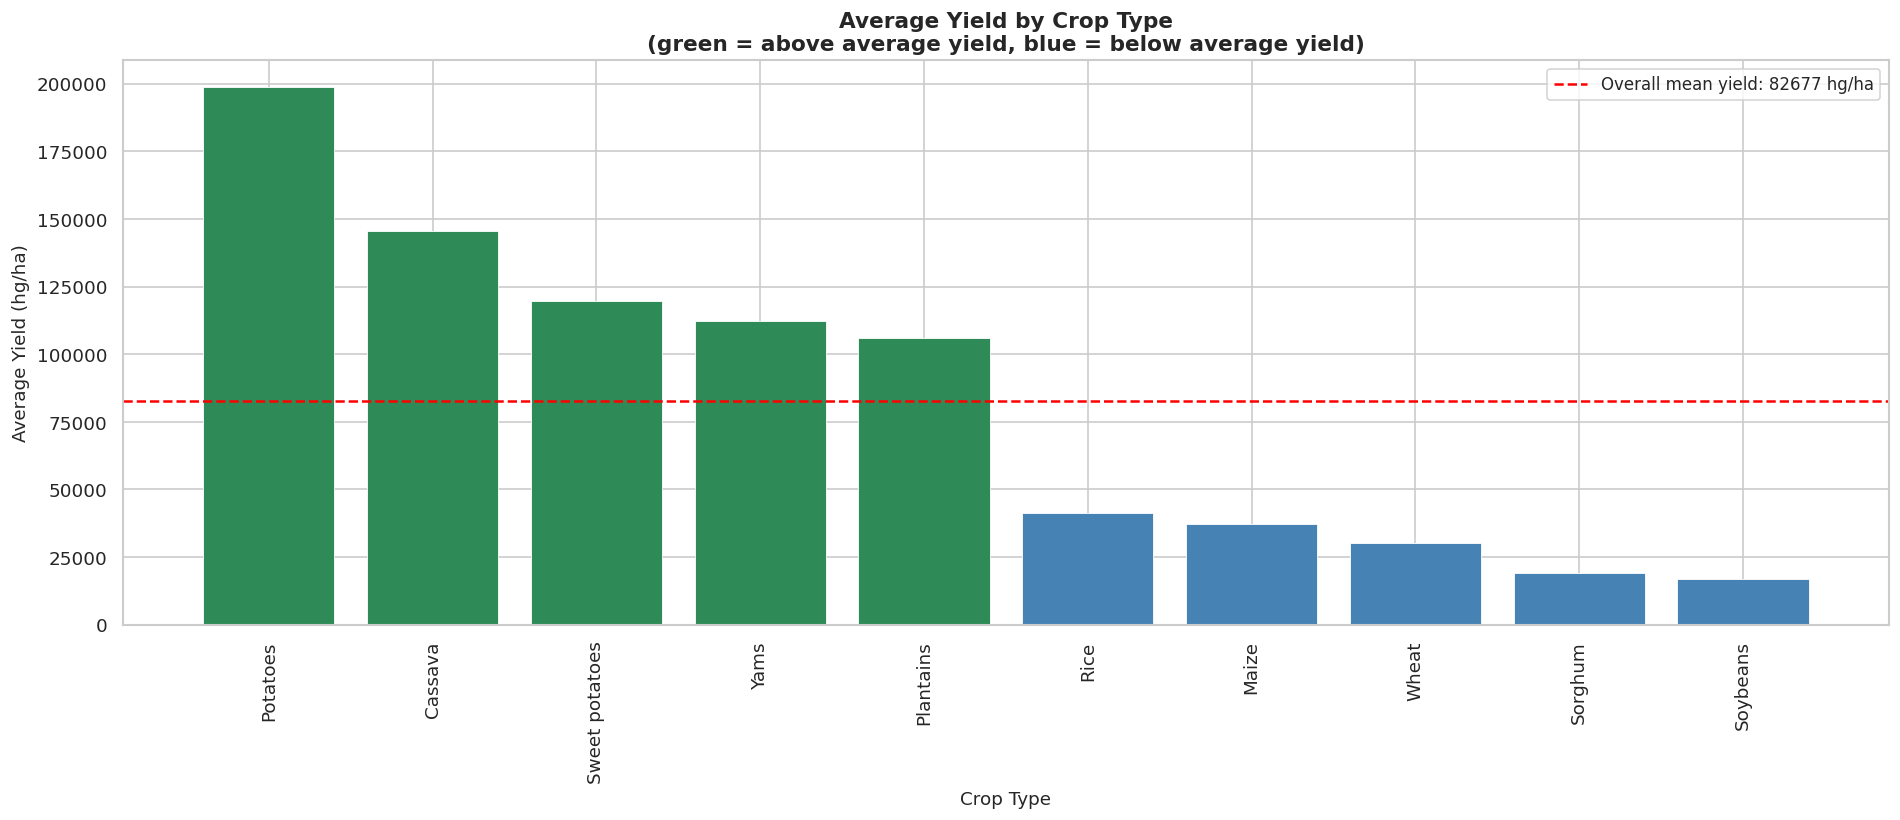


Highest yielding crop : Potatoes (198,666 hg/ha)
Lowest yielding crop  : Soybeans (16,992 hg/ha)
Overall mean yield    : 82,677 hg/ha


In [143]:
fig, ax = plt.subplots(figsize=(16, 7))

avg_yield_by_crop = (df_eda.groupby('Item')['hg/ha_yield']
                           .mean()
                           .sort_values(ascending=False))

colors = ['seagreen' if v > avg_yield_by_crop.mean()
          else 'steelblue'
          for v in avg_yield_by_crop.values]

bars = ax.bar(
    avg_yield_by_crop.index,
    avg_yield_by_crop.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

ax.axhline(
    avg_yield_by_crop.mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f'Overall mean yield: {avg_yield_by_crop.mean():.0f} hg/ha'
)

ax.set_title(
    'Average Yield by Crop Type\n'
    '(green = above average yield, blue = below average yield)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Crop Type', fontsize=11)
ax.set_ylabel('Average Yield (hg/ha)', fontsize=11)
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nHighest yielding crop : {avg_yield_by_crop.index[0]} "
      f"({avg_yield_by_crop.iloc[0]:,.0f} hg/ha)")
print(f"Lowest yielding crop  : {avg_yield_by_crop.index[-1]} "
      f"({avg_yield_by_crop.iloc[-1]:,.0f} hg/ha)")
print(f"Overall mean yield    : {avg_yield_by_crop.mean():,.0f} hg/ha")


#### Yield Signal by Crop Type — Observations

- Average yield varies dramatically across crop types — from
  198,66 hg/ha down to 16,992 hg/ha.
- The highest yielding crops are potatoes, cassava, and sweet potatoes — all
  sitting well above the overall mean yield line.
- The lowest yielding crops are soybeans, sorghum, and wheat.
- This large variation in average yield across crop types
  confirms that `Item` carries strong predictive signal —
  knowing the crop type alone tells you a great deal about
  what yield range to expect.
- Combined with the country imbalance findings above, this
  means `Item` is likely to be one of the most important
  features in the final model — a hypothesis that will be
  confirmed by the feature importance analysis after training.

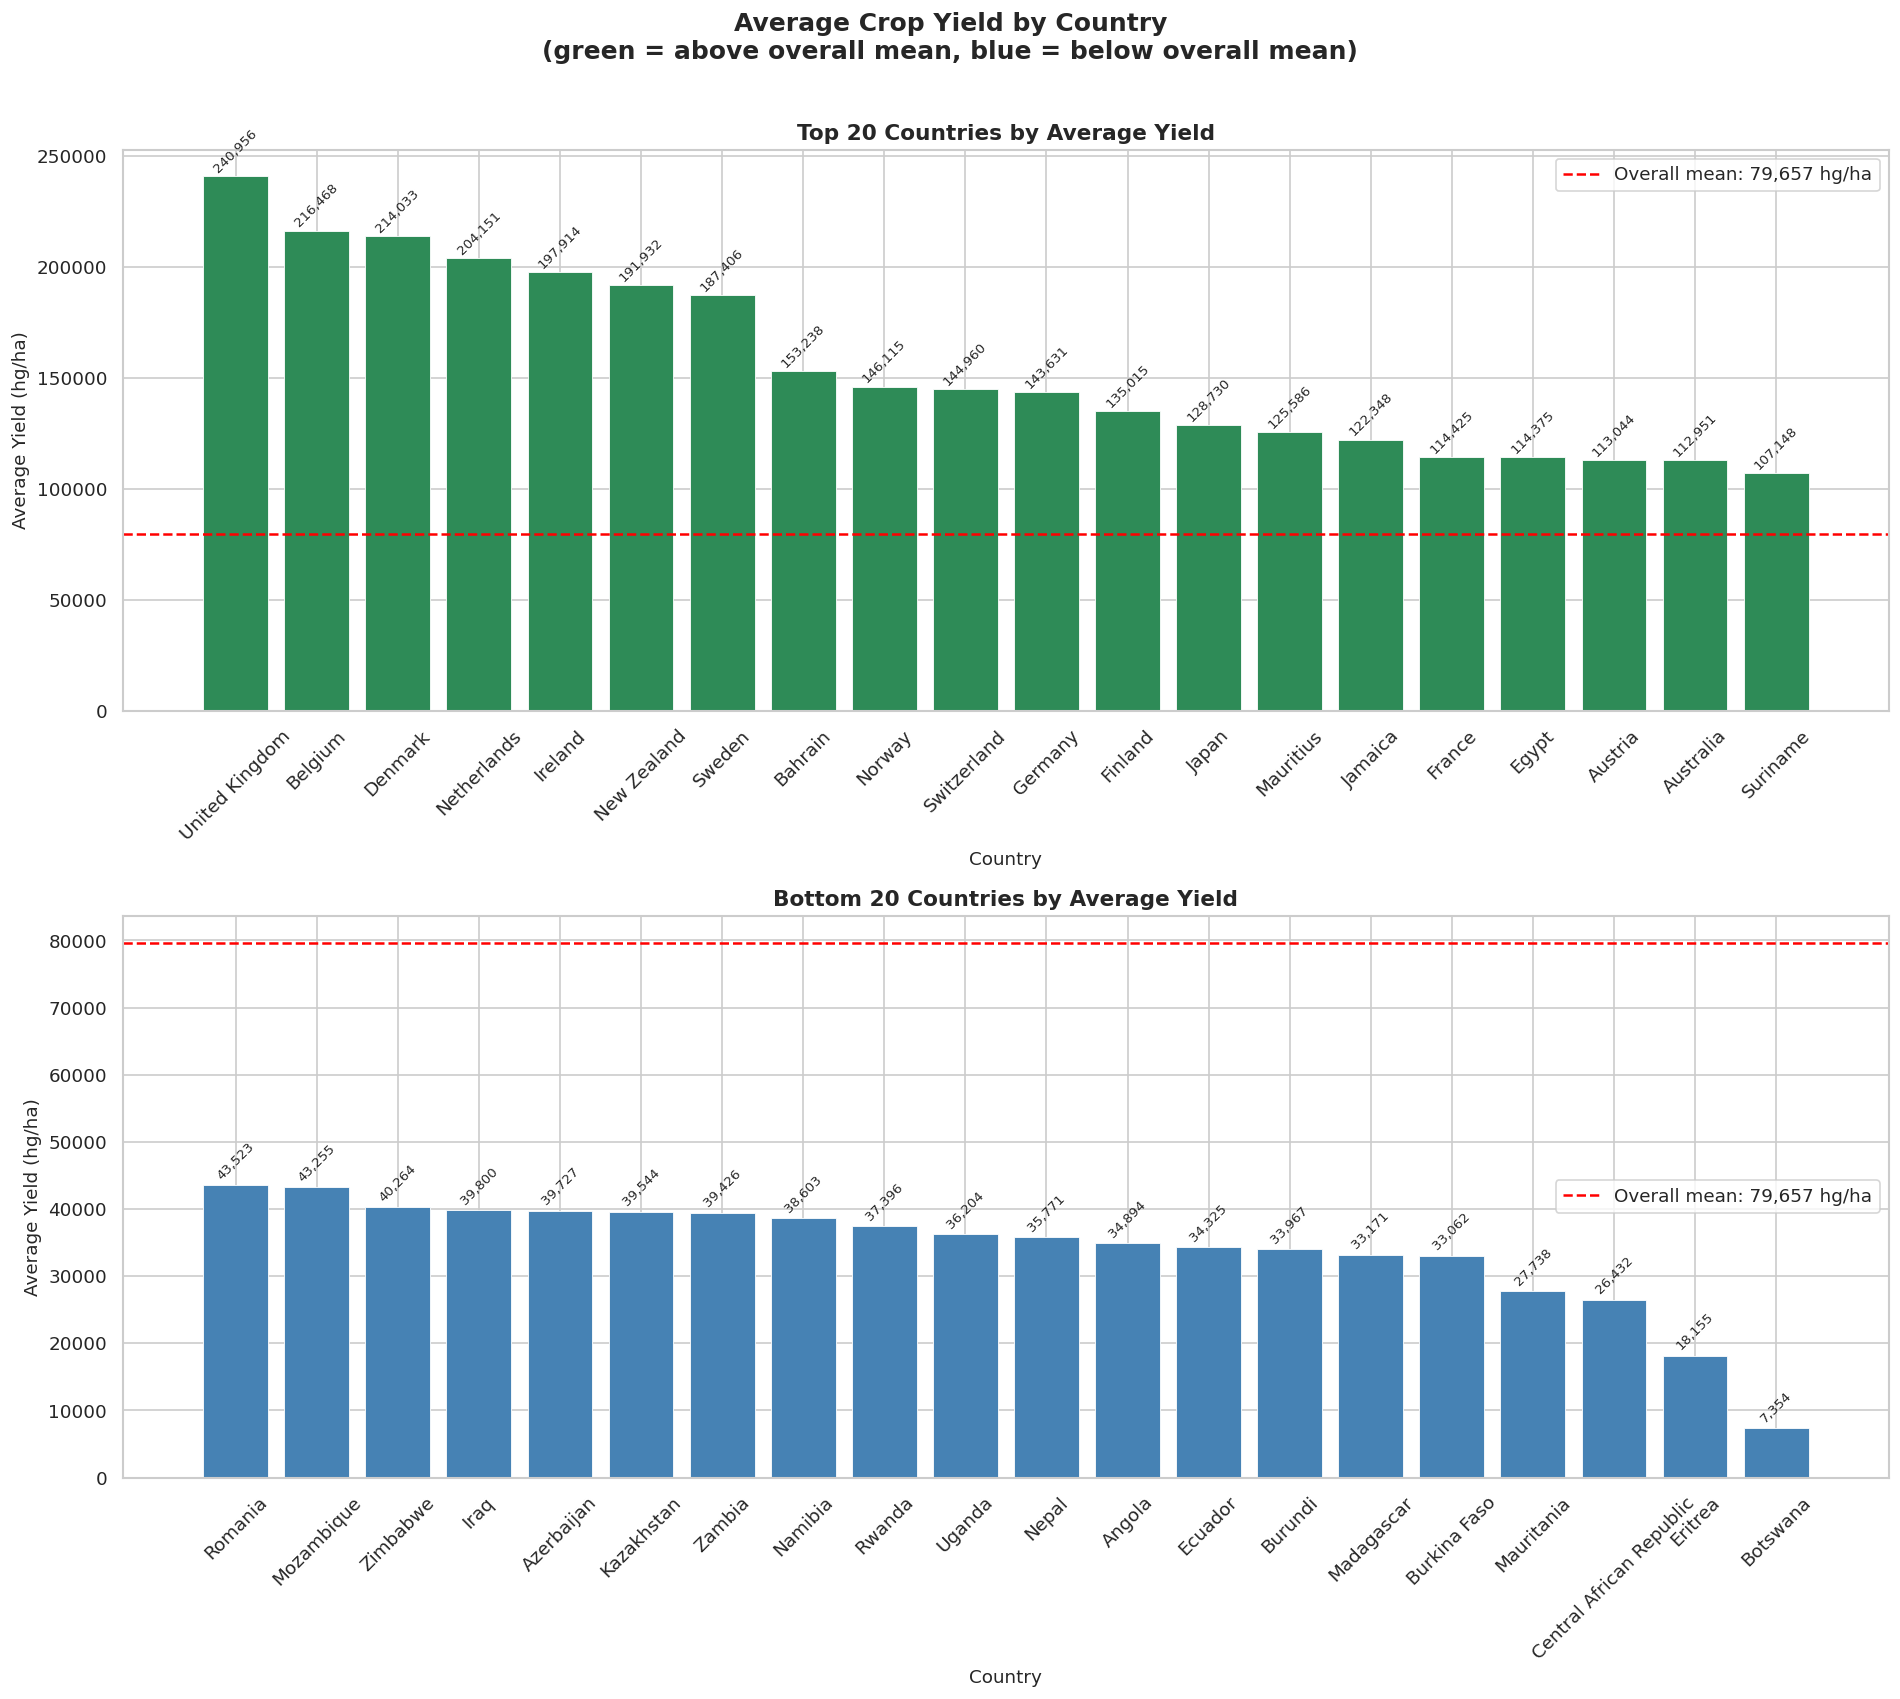

YIELD BY COUNTRY — SUMMARY
Highest yielding country : United Kingdom (240,956 hg/ha)
Lowest yielding country  : Botswana (7,354 hg/ha)
Overall mean yield       : 79,657 hg/ha
Yield range across countries: 233,603 hg/ha


In [144]:
fig, axes = plt.subplots(2, 1, figsize=(16, 14))

mean_yield_country = (df_eda.groupby('Area')['hg/ha_yield']
                             .mean()
                             .sort_values(ascending=False))

overall_mean = mean_yield_country.mean()

# --- Top 20 countries ---
top20 = mean_yield_country.head(20)

colors_top = ['seagreen' if v > overall_mean
              else 'steelblue'
              for v in top20.values]

axes[0].bar(
    top20.index,
    top20.values,
    color=colors_top,
    edgecolor='white',
    linewidth=0.5
)
axes[0].axhline(
    overall_mean,
    color='red', linestyle='--', linewidth=1.5,
    label=f'Overall mean: {overall_mean:,.0f} hg/ha'
)
axes[0].set_title('Top 20 Countries by Average Yield',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Country', fontsize=11)
axes[0].set_ylabel('Average Yield (hg/ha)', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# Add value labels on top of each bar
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{bar.get_height():,.0f}',
        ha='center', va='bottom',
        fontsize=8, rotation=45
    )

# --- Bottom 20 countries ---
bottom20 = mean_yield_country.tail(20)

colors_bottom = ['seagreen' if v > overall_mean
                 else 'steelblue'
                 for v in bottom20.values]

axes[1].bar(
    bottom20.index,
    bottom20.values,
    color=colors_bottom,
    edgecolor='white',
    linewidth=0.5
)
axes[1].axhline(
    overall_mean,
    color='red', linestyle='--', linewidth=1.5,
    label=f'Overall mean: {overall_mean:,.0f} hg/ha'
)
axes[1].set_title('Bottom 20 Countries by Average Yield',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Country', fontsize=11)
axes[1].set_ylabel('Average Yield (hg/ha)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

# Add value labels on top of each bar
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{bar.get_height():,.0f}',
        ha='center', va='bottom',
        fontsize=8, rotation=45
    )

plt.suptitle(
    'Average Crop Yield by Country\n'
    '(green = above overall mean, blue = below overall mean)',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 55)
print("YIELD BY COUNTRY — SUMMARY")
print("=" * 55)
print(f"Highest yielding country : {mean_yield_country.index[0]} "
      f"({mean_yield_country.iloc[0]:,.0f} hg/ha)")
print(f"Lowest yielding country  : {mean_yield_country.index[-1]} "
      f"({mean_yield_country.iloc[-1]:,.0f} hg/ha)")
print(f"Overall mean yield       : {overall_mean:,.0f} hg/ha")
print(f"Yield range across countries: "
      f"{mean_yield_country.max() - mean_yield_country.min():,.0f} hg/ha")

#### Average Yield by Country — Observations

- The highest yielding country is United Kingdom with an average yield
  of 240,956 hg/ha — sitting well above the overall country mean
  of 79,657 hg/ha.
- The lowest yielding country is Botswana with an average yield
  of 7,354 hg/ha.
- The yield range across all countries is 233,603 hg/ha — a large spread confirming that country is a
  strong predictor of yield.
- The majority of the top 20 countries sit well above the overall mean line while the bottom 20
  sit well below it.
- Combined with the crop type yield analysis, this confirms
  that both categorical features — Area and Item — carry
  strong predictive signal and will be important inputs
  for the model.


#### Categorical Features — Yield Signal Summary

Both categorical features carry **strong predictive signal** for crop yield:

- Average yield varies dramatically across crop types — from the highest to lowest
  yielding crops, a range of thousands of hg/ha. Knowing the crop type alone gives
  strong information about expected yield range.
- Average yield varies considerably across countries — the United Kingdom (240,956 hg/ha)
  vs Botswana (7,354 hg/ha) — a range of 233,603 hg/ha confirming country is a
  strong predictor.

Both `Area` and `Item` are therefore retained as important inputs for the model.
Their relationship with yield is captured through one-hot encoding in the
preprocessing pipeline.


### 5.3 Feature vs Target Scatter Plots

Each numerical feature is plotted against `hg/ha_yield` with a linear trend line
to understand the direction and nature of each relationship.


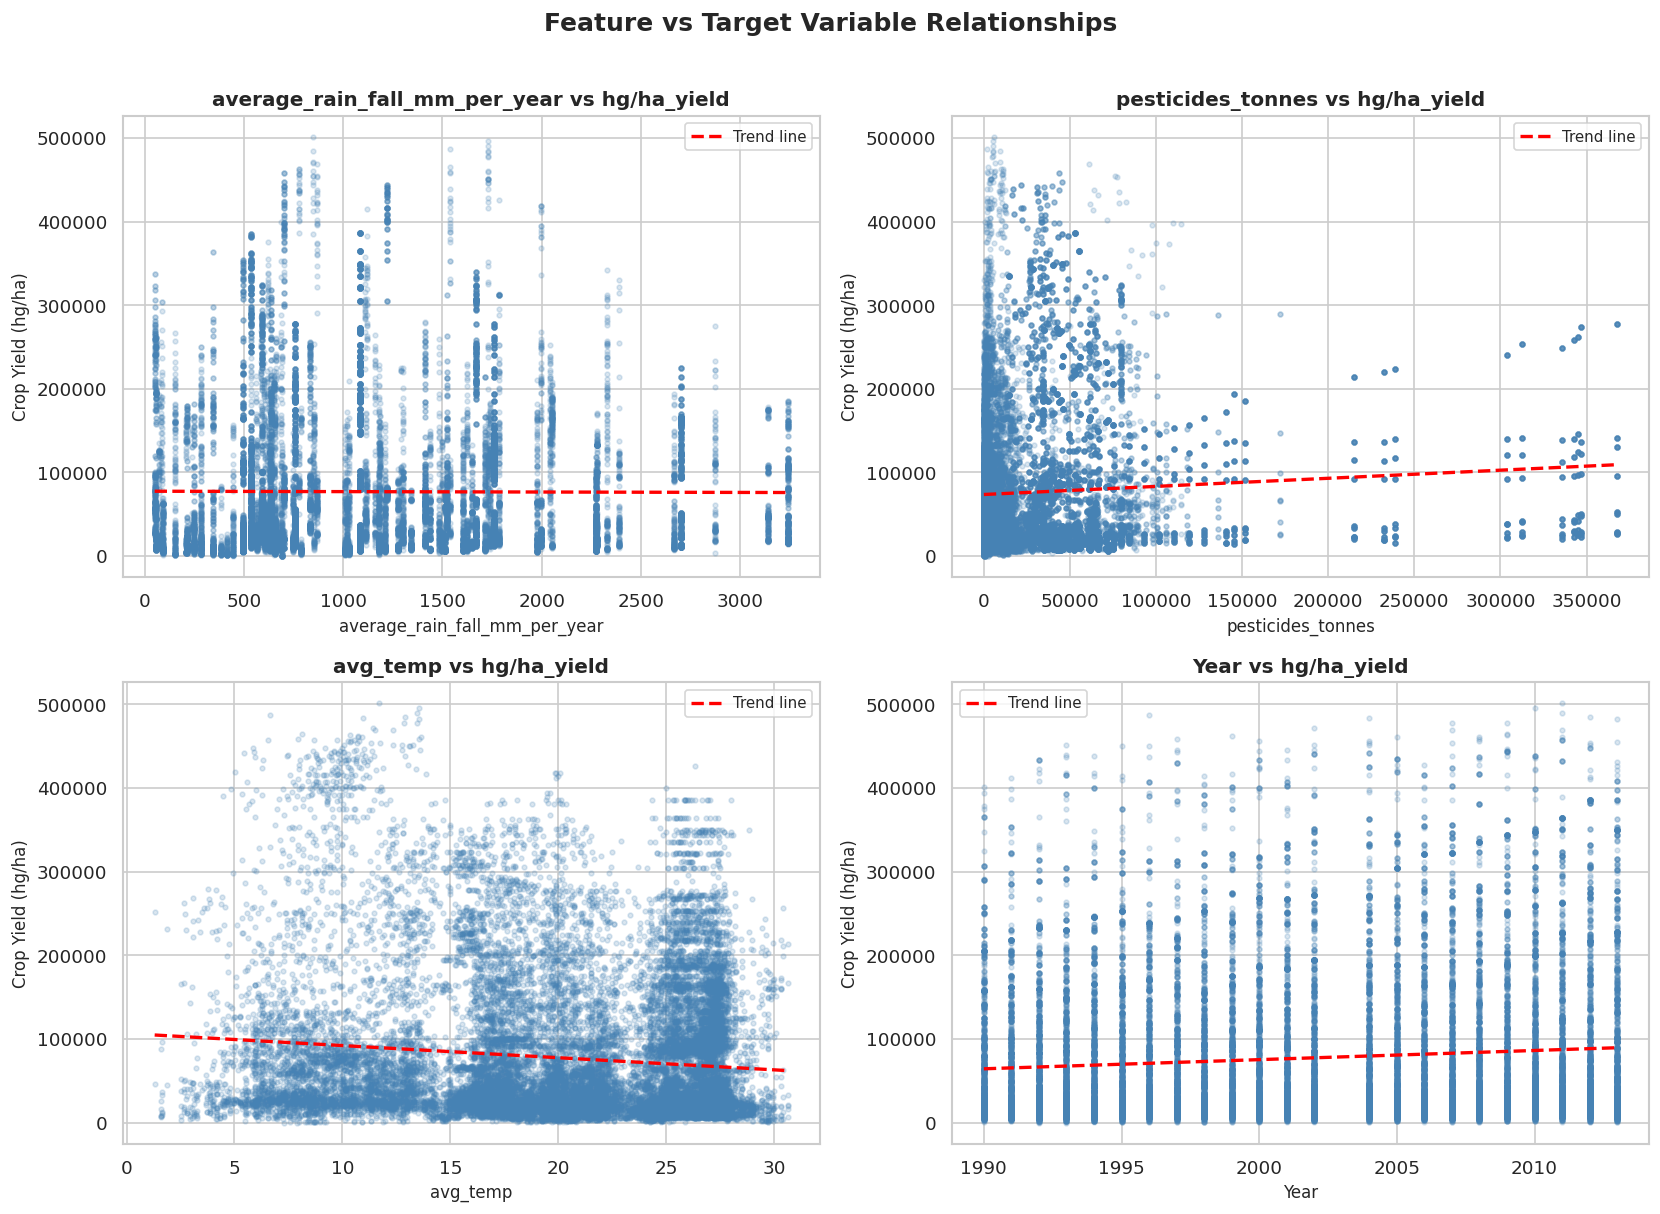

In [145]:
features = [
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp',
    'Year'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(
        df_eda[feature],
        df_eda['hg/ha_yield'],
        alpha=0.2,
        color='steelblue',
        s=8
    )

    # Add a trend line
    z = np.polyfit(
        df_eda[feature].dropna(),
        df_eda['hg/ha_yield'].dropna(),
        1
    )
    p = np.poly1d(z)
    x_line = np.linspace(
        df_eda[feature].min(),
        df_eda[feature].max(),
        100
    )
    axes[i].plot(
        x_line, p(x_line),
        color='red', linewidth=2,
        linestyle='--', label='Trend line'
    )

    axes[i].set_title(f'{feature} vs hg/ha_yield',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Crop Yield (hg/ha)', fontsize=10)
    axes[i].legend(fontsize=9)

plt.suptitle('Feature vs Target Variable Relationships',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Scatter Plot Observations

The scatter plots for all numerical features show considerable spread around the
trend lines. This is expected for three reasons:

1. **Dominant categorical drivers:** Crop type and country are the primary drivers
   of yield variance. Any single numerical feature plotted against yield in isolation
   appears noisy because records from fundamentally different crop types and countries
   are mixed on the same chart.

2. **Multivariate relationships:** No single feature explains yield independently.
   The model learns from all features simultaneously — the real predictive pattern
   only emerges when numerical and categorical features are considered together.

3. **Non-linear relationships:** The relationships are unlikely to be well-captured
   by straight lines — further reinforcing the choice of tree-based models which
   detect non-linear boundaries that linear models cannot.


### 5.4 Yield Trends Over Time


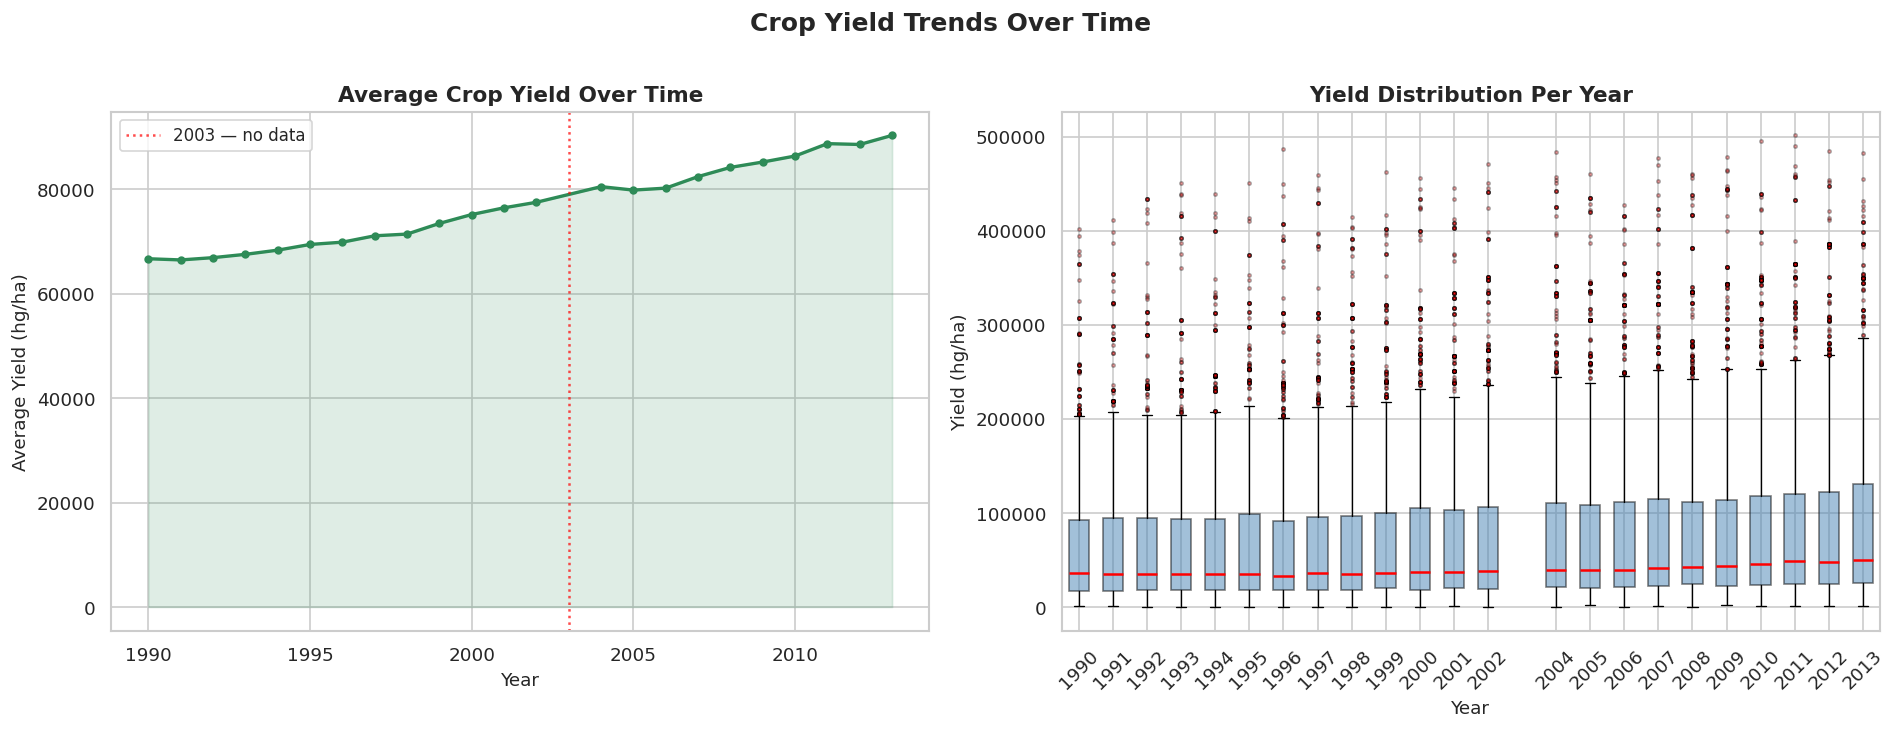

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — average yield per year trend line
avg_yield_by_year = (df_eda.groupby('Year')['hg/ha_yield']
                           .mean()
                           .reset_index())

axes[0].plot(
    avg_yield_by_year['Year'],
    avg_yield_by_year['hg/ha_yield'],
    color='seagreen', linewidth=2,
    marker='o', markersize=4
)
axes[0].fill_between(
    avg_yield_by_year['Year'],
    avg_yield_by_year['hg/ha_yield'],
    alpha=0.15, color='seagreen'
)
axes[0].set_title('Average Crop Yield Over Time',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Average Yield (hg/ha)', fontsize=11)

# Mark the missing year visually on the trend plot
axes[0].axvline(2003, color='red', linestyle=':',
                linewidth=1.5, alpha=0.7,
                label='2003 — no data')
axes[0].legend(fontsize=10)

# Right — yield spread per year
years = sorted(df_eda['Year'].unique())
yield_by_year = [
    df_eda[df_eda['Year'] == yr]['hg/ha_yield'].values
    for yr in years
]

axes[1].boxplot(
    yield_by_year,
    positions=years,
    widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5),
    medianprops=dict(color='red', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='red',
                    markersize=2, alpha=0.3),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8)
)
axes[1].set_title('Yield Distribution Per Year',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Yield (hg/ha)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Crop Yield Trends Over Time',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [147]:
print("=" * 55)
print("YEAR COVERAGE CHECK")
print("=" * 55)

all_years    = set(range(df_eda['Year'].min(),
                         df_eda['Year'].max() + 1))
present_years  = set(df_eda['Year'].unique())
missing_years  = sorted(all_years - present_years)

print(f"Expected year range : {df_eda['Year'].min()} "
      f"to {df_eda['Year'].max()}")
print(f"Total years expected: {len(all_years)}")
print(f"Total years present : {len(present_years)}")
print(f"Missing years       : {missing_years}")

print(f"\nRecord counts per year:")
print(df_eda['Year'].value_counts().sort_index())

YEAR COVERAGE CHECK
Expected year range : 1990 to 2013
Total years expected: 24
Total years present : 23
Missing years       : [2003]

Record counts per year:
Year
1990    1063
1991    1063
1992    1126
1993    1130
1994    1112
1995    1129
1996    1121
1997    1115
1998    1115
1999    1123
2000    1129
2001    1128
2002    1127
2004    1141
2005    1127
2006    1135
2007    1148
2008    1150
2009    1123
2010    1151
2011    1145
2012    1166
2013    1165
Name: count, dtype: int64


In [148]:
print("=" * 55)
print("2003 GAP — DEEPER INVESTIGATION")
print("=" * 55)

# Check years immediately around 2003
surrounding_years = [2001, 2002, 2004, 2005]

for yr in surrounding_years:
    count = len(df_eda[df_eda['Year'] == yr])
    print(f"Year {yr} : {count} records")

# Check if the gap affects all countries or just some
print(f"\nCountries present in 2002 : "
      f"{df_eda[df_eda['Year'] == 2002]['Area'].nunique()}")
print(f"Countries present in 2004 : "
      f"{df_eda[df_eda['Year'] == 2004]['Area'].nunique()}")

# Check if all crop types are affected
print(f"\nCrop types in 2002 : "
      f"{df_eda[df_eda['Year'] == 2002]['Item'].nunique()}")
print(f"Crop types in 2004 : "
      f"{df_eda[df_eda['Year'] == 2004]['Item'].nunique()}")

2003 GAP — DEEPER INVESTIGATION
Year 2001 : 1128 records
Year 2002 : 1127 records
Year 2004 : 1141 records
Year 2005 : 1127 records

Countries present in 2002 : 99
Countries present in 2004 : 99

Crop types in 2002 : 10
Crop types in 2004 : 10


#### Data Gap — Year 2003

Investigation revealed that the year 2003 is completely absent from the dataset —
no records exist for any country or crop type for that year. The surrounding years
2002 and 2004 both contain normal record counts, confirming this is a gap in the
original data source rather than a cleaning issue.

**Decision:** No imputation or fabrication of 2003 records was performed. Generating
synthetic rows for an entire year would constitute data fabrication rather than data
cleaning and would introduce artificial patterns into model training.

**Impact assessment:** The dataset covers 23 out of 24 years between 1990 and 2013
— a 4.2% temporal gap. Given that Year is one of five input features and the gap
affects all countries and crops equally, the impact on model performance is expected
to be minimal. This is noted as a known dataset limitation.


### Relationship Analysis — Overall Observations

**Feature vs Target Correlations:**
- The strongest predictor of crop yield among numerical features
  is avg_temp with a correlation of -0.110.(This is a negligible correlation)
- The weakest predictor is average_rain_fall_mm_per_year with a correlation of -0.004.
- The scatter plots reveal that relationships between features
  and yield are non-linear — further
  reinforcing the choice of tree based models which can capture
  non-linear patterns that linear models cannot.

**Multicollinearity:**
- No concerning multicollinearity was found between features

**Yield Trend Over Time:**
- Average crop yield shows a increasing
  trend between 1990 and 2013.
- This suggests that Year is a meaningful predictor
  of yield — agricultural productivity has improved steadily
  over time.
- The spread of yield values per year shown in the right plot remains fairly stable over time, indicating
  that yield variance across countries and crops is
 stable over the dataset period.

**Summary of EDA Findings:**
All key relationships have now been examined. The findings from
this correlation and relationship analysis, combined with the
distribution and outlier analyses above, provide a complete
picture of the dataset and directly inform the feature engineering
and modelling decisions in the next section.

---
## Section 6 — Data Cleaning

This section formally applies all cleaning steps identified during EDA.
The cleaning process follows a deliberate order — structural issues are
addressed first (duplicates, missing values) before categorical inconsistencies
are fixed, ensuring each step builds on a progressively cleaner dataset.

**Cleaning steps:**
1. Drop redundant index column (`Unnamed: 0`) if present
2. Remove duplicate rows
3. Verify missing values (none expected)
4. Fix inconsistent categorical labels
5. Outlier treatment decision (documented)
6. Verify and fix data types
7. Final dataset verification

All cleaning logic is also implemented in `src/data_cleaning.py` as a reusable
function for use in the training pipeline.


In [149]:
# Always clean a copy — never overwrite raw data directly
# This preserves df as the original for reference if needed
df_clean = df.copy()

print(f"Working copy created.")
print(f"Shape: {df_clean.shape}")
print(f"\nFirst 3 rows:")
display(df_clean.head(3))

Working copy created.
Shape: (28242, 7)

First 3 rows:


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37


### Step 1 — Drop Unnamed Index Column


In [150]:
# --- Fix 0: Drop Unnamed index column if present ---
if 'Unnamed: 0' in df_clean.columns:
    df_clean.drop(columns=['Unnamed: 0'], inplace=True)
    print("Fix 0 applied: 'Unnamed: 0' column dropped")
else:
    print("Fix 0: 'Unnamed: 0' not present — skipping")

Fix 0: 'Unnamed: 0' not present — skipping


### Step 2 — Remove Duplicate Rows

Duplicate rows were identified during EDA (2,310 rows). They are removed here
keeping the first occurrence. No information is lost since the rows are identical.


In [151]:
before = len(df_clean)

df_clean.drop_duplicates(keep='first', inplace=True)

after  = len(df_clean)
removed = before - after

print("=" * 50)
print("DUPLICATE REMOVAL")
print("=" * 50)
print(f"Rows before : {before:,}")
print(f"Rows after  : {after:,}")
print(f"Rows removed: {removed:,}")
print(f"\nVerification — duplicates remaining: "
      f"{df_clean.duplicated().sum()}")


DUPLICATE REMOVAL
Rows before : 28,242
Rows after  : 25,932
Rows removed: 2,310

Verification — duplicates remaining: 0


### Step 3 — Handle Missing Values

No missing values were found during EDA. This step is included explicitly to
document that missing value handling was considered and verified rather than overlooked.


In [152]:
print("=" * 50)
print("MISSING VALUE VERIFICATION")
print("=" * 50)

missing = df_clean.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

if missing.sum() == 0:
    print("\nConfirmed — no missing values present.")
    print("No imputation required.")
else:
    print("\nWarning — missing values found.")
    print("Review and apply appropriate imputation strategy.")

MISSING VALUE VERIFICATION
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Total missing values: 0

Confirmed — no missing values present.
No imputation required.


### Step 4 — Fix Inconsistent Categorical Labels

Two categorical label issues identified during EDA are corrected here.  
See Section 3.3 for full investigation and justification.


In [153]:
print("=" * 50)
print("CATEGORICAL LABEL FIXES")
print("=" * 50)

# --- Before fix ---
print("\nUnique crop types before fix:")
print(sorted(df_clean['Item'].unique()))

# --- Fix 1: Rice, paddy → Rice ---
df_clean['Item'] = df_clean['Item'].replace(
    {'Rice, paddy': 'Rice'}
)
print("\nFix 1 applied: 'Rice, paddy' → 'Rice'")

# --- Fix 2: Plantains and others → Plantains ---
df_clean['Item'] = df_clean['Item'].replace(
    {'Plantains and others': 'Plantains'}
)
print("Fix 2 applied: 'Plantains and others' → 'Plantains'")

# --- After fix ---
print("\nUnique crop types after fix:")
print(sorted(df_clean['Item'].unique()))

# --- Verification ---
print("\nVerification:")
print(f"'Rice, paddy' remaining     : "
      f"{(df_clean['Item'] == 'Rice, paddy').sum()}")
print(f"'Plantains and others' remaining: "
      f"{(df_clean['Item'] == 'Plantains and others').sum()}")

CATEGORICAL LABEL FIXES

Unique crop types before fix:
['Cassava', 'Maize', 'Plantains and others', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']

Fix 1 applied: 'Rice, paddy' → 'Rice'
Fix 2 applied: 'Plantains and others' → 'Plantains'

Unique crop types after fix:
['Cassava', 'Maize', 'Plantains', 'Potatoes', 'Rice', 'Sorghum', 'Soybeans', 'Sweet potatoes', 'Wheat', 'Yams']

Verification:
'Rice, paddy' remaining     : 0
'Plantains and others' remaining: 0


### Step 5 — Outlier Treatment

Outliers were formally detected and investigated in Section 4. The investigation
confirmed that extreme values in `pesticides_tonnes` and `hg/ha_yield` represent
genuine agricultural patterns rather than data errors. All outliers are **retained**.

Justification:
1. Confirmed as real values — concentrated in specific countries and crop types
2. Random Forest and Gradient Boosting are naturally robust to outliers
3. Removing them would discard genuine signal the model should learn from

*No outlier treatment applied.*


### Step 6 — Data Type Verification and Fixes


In [154]:
print("=" * 50)
print("DATA TYPE VERIFICATION")
print("=" * 50)

print("\nCurrent data types:")
print(df_clean.dtypes)

print(f"\nExpected types:")
print(f"  Area                          : object  (categorical)")
print(f"  Item                          : object  (categorical)")
print(f"  Year                          : int64   (numerical)")
print(f"  hg/ha_yield                   : float64 (numerical)")
print(f"  average_rain_fall_mm_per_year : float64 (numerical)")
print(f"  pesticides_tonnes             : float64 (numerical)")
print(f"  avg_temp                      : float64 (numerical)")

DATA TYPE VERIFICATION

Current data types:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Expected types:
  Area                          : object  (categorical)
  Item                          : object  (categorical)
  Year                          : int64   (numerical)
  hg/ha_yield                   : float64 (numerical)
  average_rain_fall_mm_per_year : float64 (numerical)
  pesticides_tonnes             : float64 (numerical)
  avg_temp                      : float64 (numerical)


In [155]:
print("=" * 50)
print("DATA TYPE FIXES")
print("=" * 50)

# Ensure correct types for all columns
type_fixes = {
    'Area'                          : 'object',
    'Item'                          : 'object',
    'Year'                          : 'int64',
    'hg/ha_yield'                   : 'float64',
    'average_rain_fall_mm_per_year' : 'float64',
    'pesticides_tonnes'             : 'float64',
    'avg_temp'                      : 'float64'
}

for col, expected_type in type_fixes.items():
    actual_type = str(df_clean[col].dtype)
    if actual_type != expected_type:
        df_clean[col] = df_clean[col].astype(expected_type)
        print(f"Fixed  : {col} → {expected_type}")
    else:
        print(f"OK     : {col} already {expected_type}")

print(f"\nData types after fixes:")
print(df_clean.dtypes)

DATA TYPE FIXES
OK     : Area already object
OK     : Item already object
OK     : Year already int64
Fixed  : hg/ha_yield → float64
OK     : average_rain_fall_mm_per_year already float64
OK     : pesticides_tonnes already float64
OK     : avg_temp already float64

Data types after fixes:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                      float64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


### Step 7 — Final Dataset Verification


In [156]:
print("=" * 50)
print("FINAL DATASET VERIFICATION")
print("=" * 50)

# Shape
print(f"\nShape             : {df_clean.shape}")

# Missing values
print(f"Missing values    : {df_clean.isnull().sum().sum()}")

# Duplicates
print(f"Duplicate rows    : {df_clean.duplicated().sum()}")

# Data types
print(f"\nData types:")
print(df_clean.dtypes)

# Categorical labels
print(f"\nUnique crop types : {df_clean['Item'].nunique()}")
print(f"Unique countries  : {df_clean['Area'].nunique()}")

# Check suspicious labels are gone
checks = {
    'Rice, paddy'          : 'Item',
    'Plantains and others' : 'Item',
    'Unnamed: 0'           : 'columns'
}

print(f"\nLabel fix verification:")
for label, location in checks.items():
    if location == 'columns':
        present = label in df_clean.columns
    else:
        present = (df_clean[location] == label).any()
    status = "FAIL — still present" if present else "PASS — removed"
    print(f"  {label:<30} : {status}")

# Numerical ranges
print(f"\nNumerical feature ranges:")
numerical_cols = [
    'Year',
    'average_rain_fall_mm_per_year',
    'pesticides_tonnes',
    'avg_temp',
    'hg/ha_yield'
]
for col in numerical_cols:
    print(f"  {col:<35}: "
          f"min={df_clean[col].min():.2f}, "
          f"max={df_clean[col].max():.2f}")

FINAL DATASET VERIFICATION

Shape             : (25932, 7)
Missing values    : 0
Duplicate rows    : 0

Data types:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                      float64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Unique crop types : 10
Unique countries  : 101

Label fix verification:
  Rice, paddy                    : PASS — removed
  Plantains and others           : PASS — removed
  Unnamed: 0                     : PASS — removed

Numerical feature ranges:
  Year                               : min=1990.00, max=2013.00
  average_rain_fall_mm_per_year      : min=51.00, max=3240.00
  pesticides_tonnes                  : min=0.04, max=367778.00
  avg_temp                           : min=1.30, max=30.65
  hg/ha_yield                        : min=50.00, max=501412.00


In [157]:
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)
print(f"Original shape      : {df.shape}")
print(f"Cleaned shape       : {df_clean.shape}")
print(f"Rows removed        : {df.shape[0] - df_clean.shape[0]:,}")
print(f"Columns removed     : {df.shape[1] - df_clean.shape[1]}")
print(f"\nMissing values      : {df_clean.isnull().sum().sum()}")
print(f"Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"\nCleaning steps applied:")
print(f"  1. Duplicate rows removed")
print(f"  2. Missing values verified — none found")
print(f"  3. Categorical labels fixed — Rice and Plantains")
print(f"  4. Outliers retained — see EDA for justification")

DATA CLEANING SUMMARY
Original shape      : (28242, 7)
Cleaned shape       : (25932, 7)
Rows removed        : 2,310
Columns removed     : 0

Missing values      : 0
Duplicates remaining: 0

Cleaning steps applied:
  1. Duplicate rows removed
  2. Missing values verified — none found
  3. Categorical labels fixed — Rice and Plantains
  4. Outliers retained — see EDA for justification


In [158]:
import os

os.makedirs('data/processed', exist_ok=True)
df_clean.to_csv('data/processed/cleaned_yield.csv', index=False)

print("Cleaned dataset saved to data/processed/cleaned_yield.csv")
print(f"Final shape: {df_clean.shape}")

Cleaned dataset saved to data/processed/cleaned_yield.csv
Final shape: (25932, 7)


### Data Cleaning Complete — Full Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Drop Unnamed index column | Removed (conditional — safe if absent) |
| 2 | Remove duplicate rows | 2,310 rows removed |
| 3 | Verify missing values | None found — no imputation required |
| 4 | Fix categorical labels | `Rice, paddy` → `Rice` · `Plantains and others` → `Plantains` |
| 5 | Outlier treatment | Retained — tree models robust, values are genuine |
| 6 | Verify data types | All columns confirmed correct |
| 7 | Final verification | All checks passed |

The cleaned dataset is saved to `data/processed/cleaned_yield.csv` and is ready
for the preprocessing pipeline.


---
## Section 7 — Feature Engineering

Feature engineering creates new columns from existing ones to give the model more
explicit and meaningful information than the raw data alone provides.

Four new features are created based on domain knowledge of agricultural patterns
and findings from EDA:

| Feature | Derived From | Rationale |
|---------|-------------|-----------|
| `years_since_1990` | Year | Temporal agricultural progress since dataset start |
| `rain_temp_interaction` | Rainfall × Temperature | Combined climate effect — heat and moisture together drive plant growth |
| `pesticides_per_rainfall` | Pesticides ÷ Rainfall | Effective concentration — heavy rainfall washes pesticides off crops |
| `avg_temp_squared` | Temperature² | Non-linear temperature-yield relationship — yield peaks at optimal temp then drops |

**Note:** Categorical encoding (`OneHotEncoder`) is intentionally excluded from
this step. It is applied inside the sklearn `Pipeline` during preprocessing to
prevent data leakage — ensuring the encoder learns category mappings from training
data only and never sees test data during fitting.


### Feature 1 — Years Since 1990

Converts raw calendar year into a measure of agricultural progress since the start
of the dataset. More meaningful to the model than a raw year number.


In [159]:
df_clean['years_since_1990'] = df_clean['Year'] - 1990

print("Feature 1 created: years_since_1990")
print(f"Range: {df_clean['years_since_1990'].min()} "
      f"to {df_clean['years_since_1990'].max()}")
print(f"\nSample values:")
print(df_clean[['Year', 'years_since_1990']].head(5))


Feature 1 created: years_since_1990
Range: 0 to 23

Sample values:
   Year  years_since_1990
0  1990                 0
1  1990                 0
2  1990                 0
3  1990                 0
4  1990                 0


In [160]:
# Drop raw Year column — now redundant since years_since_1990
# captures the same temporal information in a more meaningful form
df_clean = df_clean.drop(columns=['Year'])

print("'Year' column dropped — replaced by 'years_since_1990'")
print(f"Columns remaining: {df_clean.columns.tolist()}")

'Year' column dropped — replaced by 'years_since_1990'
Columns remaining: ['Area', 'Item', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'years_since_1990']


### Feature 2 — Rainfall × Temperature Interaction

Rainfall and temperature do not affect yield independently — they interact. A hot
dry climate produces completely different agricultural outcomes from a hot wet climate
even at identical temperatures. This interaction feature captures the combined climate
effect that neither variable expresses alone.


In [161]:
df_clean['rain_temp_interaction'] = (
    df_clean['average_rain_fall_mm_per_year'] * df_clean['avg_temp']
)

print("Feature 2 created: rain_temp_interaction")
print(f"Min  : {df_clean['rain_temp_interaction'].min():.2f}")
print(f"Max  : {df_clean['rain_temp_interaction'].max():.2f}")
print(f"Mean : {df_clean['rain_temp_interaction'].mean():.2f}")
print(f"\nSample values:")
print(df_clean[['average_rain_fall_mm_per_year',
                'avg_temp',
                'rain_temp_interaction']].head(5))


Feature 2 created: rain_temp_interaction
Min  : 402.50
Max  : 89974.80
Mean : 24962.45

Sample values:
   average_rain_fall_mm_per_year  avg_temp  rain_temp_interaction
0                         1485.0     16.37               24309.45
1                         1485.0     16.37               24309.45
2                         1485.0     16.37               24309.45
3                         1485.0     16.37               24309.45
4                         1485.0     16.37               24309.45


### Feature 3 — Pesticides Per Rainfall

Heavy rainfall can wash pesticides off crops before they take effect, reducing their
agricultural impact. This ratio captures the effective pesticide concentration that
actually remains on crops. A small epsilon (1e-6) is added to the denominator to
prevent division by zero.


In [162]:
# Add small constant to avoid division by zero
df_clean['pesticides_per_rainfall'] = (
    df_clean['pesticides_tonnes'] /
    (df_clean['average_rain_fall_mm_per_year'] + 1e-6)
)

print("Feature 3 created: pesticides_per_rainfall")
print(f"Min  : {df_clean['pesticides_per_rainfall'].min():.4f}")
print(f"Max  : {df_clean['pesticides_per_rainfall'].max():.4f}")
print(f"Mean : {df_clean['pesticides_per_rainfall'].mean():.4f}")
print(f"\nSample values:")
print(df_clean[['pesticides_tonnes',
                'average_rain_fall_mm_per_year',
                'pesticides_per_rainfall']].head(5))


Feature 3 created: pesticides_per_rainfall
Min  : 0.0000
Max  : 290.9400
Mean : 35.2570

Sample values:
   pesticides_tonnes  average_rain_fall_mm_per_year  pesticides_per_rainfall
0              121.0                         1485.0                 0.081481
1              121.0                         1485.0                 0.081481
2              121.0                         1485.0                 0.081481
3              121.0                         1485.0                 0.081481
4              121.0                         1485.0                 0.081481


### Feature 4 — Average Temperature Squared

Crop growth follows a non-linear relationship with temperature — yield increases
toward an optimal growing temperature then drops sharply beyond it. A squared term
gives the model the ability to learn this curved relationship that a linear feature
cannot express.


In [163]:
df_clean['avg_temp_squared'] = df_clean['avg_temp'] ** 2

print("Feature 4 created: avg_temp_squared")
print(f"Min  : {df_clean['avg_temp_squared'].min():.2f}")
print(f"Max  : {df_clean['avg_temp_squared'].max():.2f}")
print(f"Mean : {df_clean['avg_temp_squared'].mean():.2f}")
print(f"\nSample values:")
print(df_clean[['avg_temp',
                'avg_temp_squared']].head(5))

Feature 4 created: avg_temp_squared
Min  : 1.69
Max  : 939.42
Mean : 458.53

Sample values:
   avg_temp  avg_temp_squared
0     16.37          267.9769
1     16.37          267.9769
2     16.37          267.9769
3     16.37          267.9769
4     16.37          267.9769


In [164]:
print("=" * 55)
print("FEATURE ENGINEERING — VERIFICATION")
print("=" * 55)

new_features = [
    'years_since_1990',
    'rain_temp_interaction',
    'pesticides_per_rainfall',
    'avg_temp_squared'
]

print(f"\nDataset shape before : {df.shape[1]} columns")
print(f"Dataset shape after  : {df_clean.shape[1]} columns")
print(f"New features added   : {len(new_features)}")

print(f"\nNew feature summary:")
print(df_clean[new_features].describe().round(2))

print(f"\nMissing values in new features:")
print(df_clean[new_features].isnull().sum())

print(f"\nFull column list:")
for i, col in enumerate(df_clean.columns):
    marker = ' ← new' if col in new_features else ''
    print(f"  {i+1:2}. {col}{marker}")

FEATURE ENGINEERING — VERIFICATION

Dataset shape before : 7 columns
Dataset shape after  : 10 columns
New features added   : 4

New feature summary:
       years_since_1990  rain_temp_interaction  pesticides_per_rainfall  \
count          25932.00               25932.00                 25932.00   
mean              11.56               24962.45                    35.26   
std                7.06               19761.68                    42.75   
min                0.00                 402.50                     0.00   
25%                5.00                9517.55                     1.26   
50%               11.00               22384.56                    25.32   
75%               18.00               33925.76                    52.85   
max               23.00               89974.80                   290.94   

       avg_temp_squared  
count          25932.00  
mean             458.53  
std              237.30  
min                1.69  
25%              274.90  
50%              4

### Feature vs Target Visualisation

Engineered features are plotted against the target variable. Note that scatter plots
for these features — like the raw numerical features — show considerable spread.
This is expected and explained in Section 5.3. The value of engineered features
will be reflected in model performance metrics and feature importance scores after
training, not in univariate scatter plots.


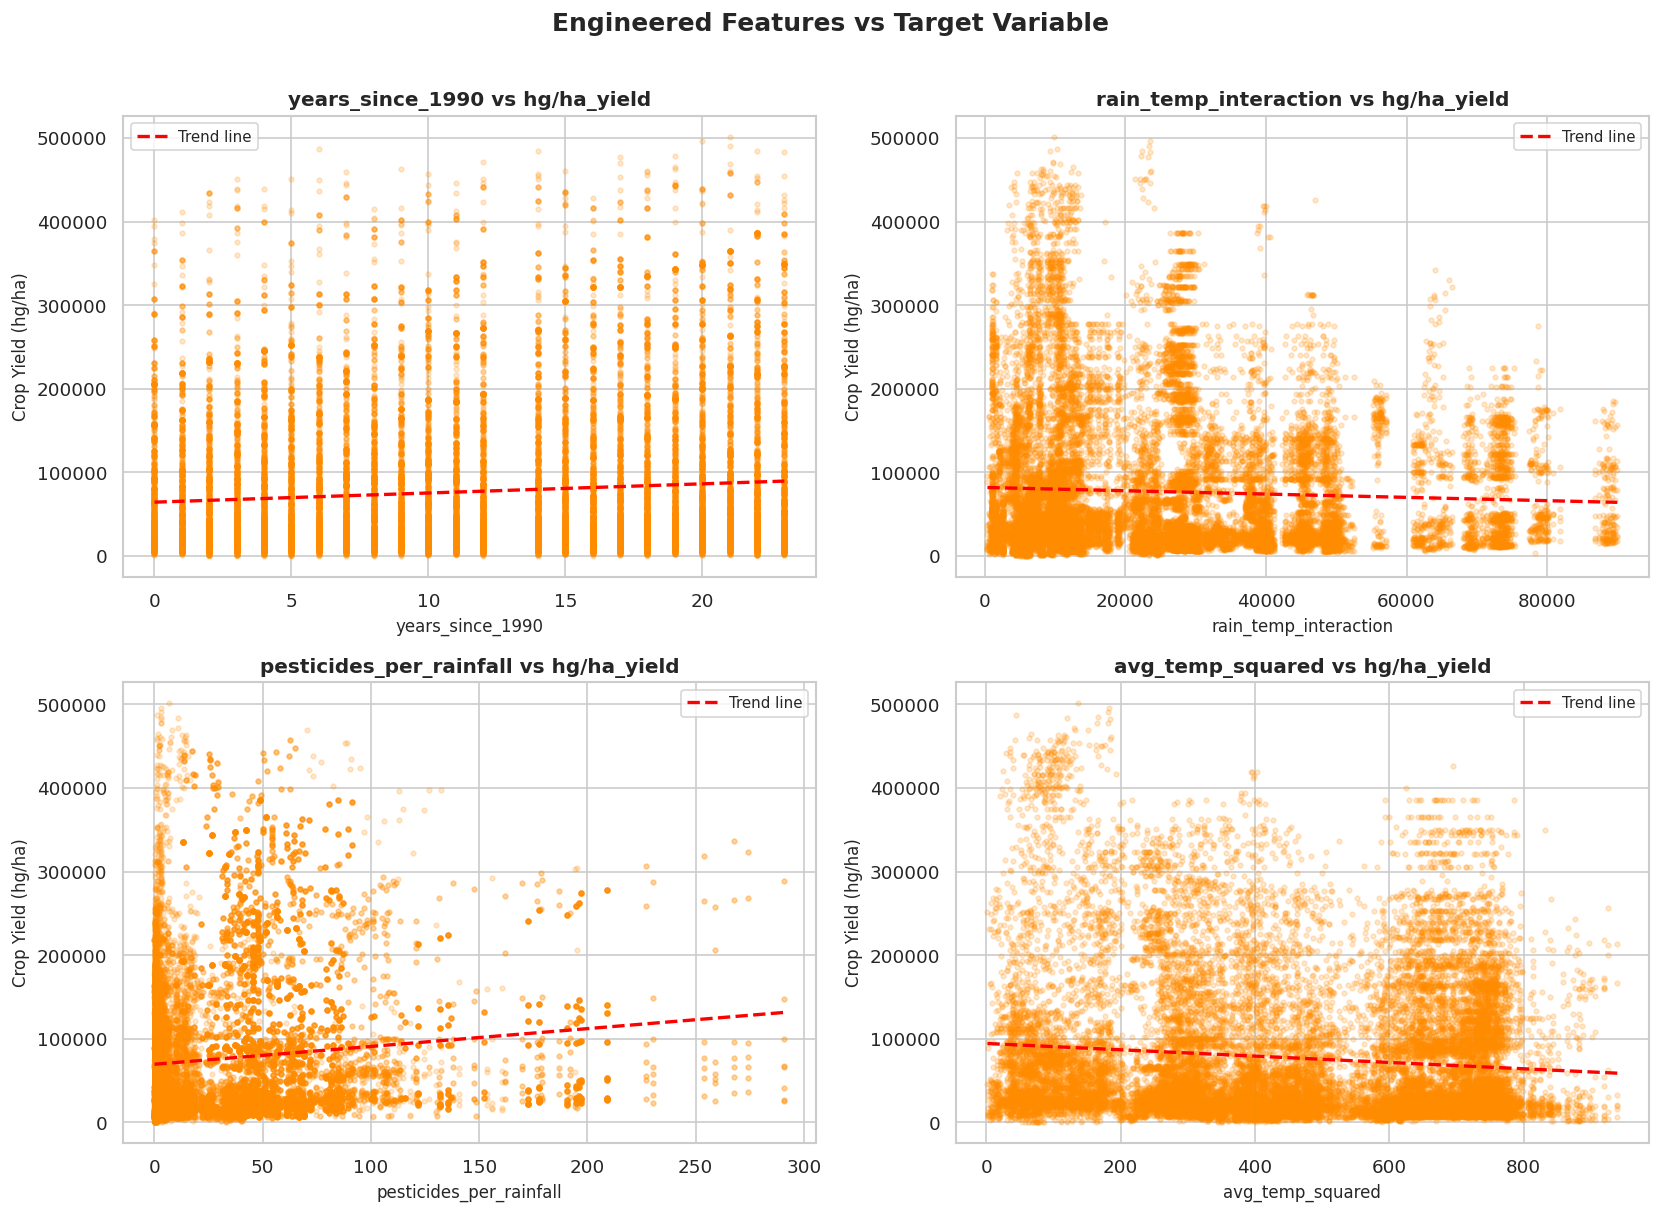

In [165]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    axes[i].scatter(
        df_clean[feature],
        df_clean['hg/ha_yield'],
        alpha=0.2,
        color='darkorange',
        s=8
    )

    # Add trend line
    z = np.polyfit(
        df_clean[feature].dropna(),
        df_clean['hg/ha_yield'].dropna(),
        1
    )
    p = np.poly1d(z)
    x_line = np.linspace(
        df_clean[feature].min(),
        df_clean[feature].max(),
        100
    )
    axes[i].plot(
        x_line, p(x_line),
        color='red', linewidth=2,
        linestyle='--', label='Trend line'
    )

    axes[i].set_title(f'{feature} vs hg/ha_yield',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Crop Yield (hg/ha)', fontsize=10)
    axes[i].legend(fontsize=9)

plt.suptitle('Engineered Features vs Target Variable',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Engineered Feature Visualisation — Observations

The scatter plots for engineered features show considerable spread around the trend
lines — consistent with the raw feature scatter plots in Section 5.3. This is expected:

1. Crop type and country are the dominant drivers of yield variance. Any numerical
   feature plotted against yield in isolation appears noisy because records from
   fundamentally different crop types and countries are mixed on the same chart.

2. The relationships are multivariate — no single feature explains yield independently.
   The real predictive pattern only emerges when all features are considered together.

3. Engineered features like `rain_temp_interaction` and `avg_temp_squared` are designed
   to capture non-linear relationships at the model level. Their value is reflected in
   model performance metrics and feature importance scores after training.


In [166]:
os.makedirs('data/processed', exist_ok=True)

df_clean.to_csv(
    'data/processed/cleaned_yield.csv',
    index=False
)

print("Updated dataset saved to data/processed/cleaned_yield.csv")
print(f"Final shape: {df_clean.shape}")
print(f"\nColumns saved:")
for col in df_clean.columns:
    print(f"  - {col}")

Updated dataset saved to data/processed/cleaned_yield.csv
Final shape: (25932, 10)

Columns saved:
  - Area
  - Item
  - hg/ha_yield
  - average_rain_fall_mm_per_year
  - pesticides_tonnes
  - avg_temp
  - years_since_1990
  - rain_temp_interaction
  - pesticides_per_rainfall
  - avg_temp_squared


### Feature Engineering Complete

The dataset now contains **10 columns** — 6 original features plus 4 engineered ones.
Saved to `data/processed/cleaned_yield.csv` and ready for the preprocessing pipeline.

---
*Next: `src/preprocessing.py` — sklearn ColumnTransformer and Pipeline construction*
